In [337]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<h1>Preliminary Phase (100)</h1>
<p>Have data frrom all sites...</p>

In [338]:
# Preliminary phase data
df_gh_prelim = pd.read_csv('../data/raw/ghana/raw/prelims.csv')
df_ml_prelim = pd.read_csv('../data/raw/mali/raw/prelims.csv', sep=',')
df_tn_prelim = pd.read_csv('../data/raw/tanzania/raw/tanzania_prelim.csv')
df_ug_prelim = pd.read_csv('../data/raw/uganda/raw/prelims.csv')
df_zim_zam_prelim = pd.concat([pd.read_csv('../data/raw/zim_zam/raw/zim.csv'), pd.read_csv('../data/raw/zim_zam/raw/zam.csv')], ignore_index=True)
df_ng_prelim = pd.read_csv('../data/raw/nigeria/raw/prelims.csv')

print('df_gh_prelim:', df_gh_prelim.shape)
print('df_ml_prelim:', df_ml_prelim.shape)
print('df_tn_prelim:', df_tn_prelim.shape)
print('df_ug_prelim:', df_ug_prelim.shape)
print('df_zim_zam_prelim:', df_zim_zam_prelim.shape)
print('df_ng_prelim:', df_ng_prelim.shape)
print(' ')
print('preliminary total:', df_gh_prelim.shape[0]+df_ml_prelim.shape[0]+df_tn_prelim.shape[0]+df_ug_prelim.shape[0]+df_zim_zam_prelim.shape[0]+df_ng_prelim.shape[0])

df_gh_prelim: (101, 82)
df_ml_prelim: (104, 219)
df_tn_prelim: (100, 52)
df_ug_prelim: (100, 94)
df_zim_zam_prelim: (200, 17)
df_ng_prelim: (100, 202)
 
preliminary total: 705


In [339]:
df_gh_prelim['country'] = 'ghana'
df_ml_prelim['country'] = 'mali'
df_tn_prelim['country'] = 'tanzania'
df_ug_prelim['country'] = 'uganda'
df_zim_zam_prelim['country'] = 'zim/zam'
df_ng_prelim['country'] = 'nigeria'

In [340]:
for i in range(len(df_gh_prelim.columns)):
    print(list(df_gh_prelim.columns)[i])
df_gh_prelim.head(2)

record_id
date_of_visit
pgage_yrs
sex_guardian
tribe_guardian
guardian_relationship
specify_relationship
marital_status_guardian
edu_level_guardian
specify_edu_level_guardian
guardian_occupation
alt_guardian_occupation
religion
mother_children_count
detection_at_birth
scd_longevity
early_detection_importance
need_immediate_result
enough_poct_info
poct_result_speed
screening_recommendation
poct_recommendation
dbs_for_validation
proper_treatment
scd_in_the_family
registry_willingness
no_followup_reasons
nofollowup_reason_specified
dob_newborn
sex_newborn
nbs_screening_locale
screening_date
kind_of_screening_test___1
kind_of_screening_test___2
kind_of_screening_test___3
kind_of_screening_test___4
kind_of_screening_test___5
kind_of_screening_test___6
alt_screening_test
tests___1
tests___2
tests___3
tests___4
tests___5
std_poct_done
std_poct_test_date
std_poct_test_result_date
std_poct_results
dbspoct_test_date
dbspoct_test_result_date
dbspoct_test_results
ief_test_date
ief_test_result_date

,record_id,date_of_visit,pgage_yrs,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,dob_newborn,sex_newborn,nbs_screening_locale,screening_date,kind_of_screening_test___1,kind_of_screening_test___2,kind_of_screening_test___3,kind_of_screening_test___4,kind_of_screening_test___5,kind_of_screening_test___6,alt_screening_test,tests___1,tests___2,tests___3,tests___4,tests___5,std_poct_done,std_poct_test_date,std_poct_test_result_date,std_poct_results,dbspoct_test_date,dbspoct_test_result_date,dbspoct_test_results,ief_test_date,ief_test_result_date,ief_test_results,hplc_test_date,hplc_result_date,hplc_results,additional_molecular_test,additional_test_date,add_molecular_result_date,add_molecula_test_results,newborn_registryid,reminder_1,reminder1_method___1,reminder1_method___2,reminder1_method___3,reminder1_method___4,alt_reminder1_method,reminder_2,reminder2_method___1,reminder2_method___2,reminder2_method___3,reminder2_method___4,alt_reminder2_method,reminder_3,reminder3_method___1,reminder3_method___2,reminder3_method___3,reminder3_method___4,alt_reminder3_method,subject_comments,call_reminders_complete,country
0,0001,20 02 2024,NaN,Female,Akan,Mother,NaN,Cohabiting,Secondary,NaN,Others,Decorator,Christian,1.0,Neutral/ I dont know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,19 02 2024,Male,At Birthing Facility,20 02 2024,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,NaN,Checked,Checked,Checked,Unchecked,Unchecked,Yes,20 02 2024,20 02 2024,AA,20 02 2024,28 03 2024,AA,19 03 2024,19 03 2024,FA - NO abnormal hemoglobin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unchecked,Unchecked,Unchecked,Unchecked,NaN,NaN,Unchecked,Unchecked,Unchecked,Unchecked,NaN,NaN,Unchecked,Unchecked,Unchecked,Unchecked,NaN,NaN,Incomplete,ghana
1,0002,20 02 2024,NaN,Female,Saliga,Mother,NaN,Married,Secondary,NaN,Others,Seamstress,Muslim,3.0,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I dont know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I dont know,Yes,Yes,NaN,19 02 2024,Female,At Birthing Facility,20 02 2024,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,NaN,Checked,Checked,Checked,Unchecked,Unchecked,Yes,20 02 2024,20 02 2024,AC,20 02 2024,28 03 2024,AA,19 03 2024,19 03 2024,FAC - C trait (AC),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unchecked,Unchecked,Unchecked,Unchecked,NaN,NaN,Unchecked,Unchecked,Unchecked,Unchecked,NaN,NaN,Unchecked,Unchecked,Unchecked,Unchecked,NaN,NaN,Incomplete,ghana


In [341]:
for i in range(len(df_ml_prelim.columns)):
    print(list(df_ml_prelim.columns)[i])
df_ml_prelim.head(2)

record_id
redcap_event_name
facility_id_screening
participant_id
date_enrolled
date_of_visit
firstname_guardian
lastname_guardian
dob_guardian
sex_guardian
tribe_guardian
guardian_relationship
specify_relationship
marital_status_guardian
edu_level_guardian
specify_edu_level_guardian
guardian_occupation
alt_guardian_occupation
religion
mother_children_count
detection_at_birth
scd_longevity
early_detection_importance
need_immediate_result
enough_poct_info
poct_result_speed
screening_recommendation
poct_recommendation
dbs_for_validation
proper_treatment
scd_in_the_family
registry_willingness
no_followup_reasons
nofollowup_reason_specified
comments
address
landmark
personal_phonenum
alt_phonenum
firstname_newborn
lastname_newborn
dob_newborn
sex_newborn
nbs_screening_locale
screening_date
kind_of_screening_test
alt_screening_test
person_collecting_samples
screening_form_complete
name_surname_newborn
name_surname_mother
std_poct_done
std_poct_test_date
std_poct_test_result_date
std_poct_res

,record_id,redcap_event_name,facility_id_screening,participant_id,date_enrolled,date_of_visit,firstname_guardian,lastname_guardian,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,comments,address,landmark,personal_phonenum,alt_phonenum,firstname_newborn,lastname_newborn,dob_newborn,sex_newborn,nbs_screening_locale,screening_date,kind_of_screening_test,alt_screening_test,person_collecting_samples,screening_form_complete,name_surname_newborn,name_surname_mother,std_poct_done,std_poct_test_date,std_poct_test_result_date,std_poct_results,dbspoct_test_date,dbspoct_test_result_date,dbspoct_test_results,hplc_test_date,hplc_result_date,hplc_results,ief_test_date,ief_test_result_date,ief_test_results,additional_molecular_test,additional_test_date,add_molecular_result_date,add_molecula_test_results,newborn_registryid,reminder_1,reminder1_method___1,reminder1_method___2,reminder1_method___3,reminder1_method___4,alt_reminder1_method,reminder1_personnel,reminder_2,reminder2_method___1,reminder2_method___2,reminder2_method___3,reminder2_method___4,alt_reminder2_method,reminder2_personnel,reminder_3,reminder3_method___1,reminder3_method___2,reminder3_method___3,reminder3_method___4,alt_reminder3_method,reminder3_personnel,subject_comments,poct_and_lab_results_complete,facilityid_hcw,studyid_hcw,age_hcw,gender_hcw,job_title_hcw___1,job_title_hcw___2,job_title_hcw___3,job_title_hcw___4,job_title_hcw___5,job_title_hcw___6,job_title_hcw___7,job_title_hcw___8,job_title_hcw___9,job_title_hcw___10,spec_hcw_jobtitle,level_of_education_hcw,specify_edu_hcw,years_experience_hcw,nbs_test_knowledge_hcw___1,nbs_test_knowledge_hcw___2,nbs_test_knowledge_hcw___3,nbs_test_knowledge_hcw___4,nbs_test_knowledge_hcw___5,nbs_test_knowledge_hcw___6,nbs_test_knowledge_hcw___7,nbs_test_knowledge_hcw___8,nbs_test_knowledge_hcw___9,nbs_test_knowledge_hcw___10,detection_at_birth_hcw,scd_longevity_hcw,early_detection_import_hcw,training_sufficient_hcw,poct_accuracy_hcw,poct_result_speed_hcw,poct_resource_needs_hcw,screening_recommend_hcw,poct_recommend_hcw,proper_treatment_hcw,screen_all_babies_here,staff_for_screening,poct_sustainability,staff_for_dbs_and_poct,scd_care_support,comments_hcw,healthcare_workers_questionnaire_complete,facility_id,facility_name,job_title_facility,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmicist_count,facility_lab_personnel_count,facility_midwife_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facility_nutritionist_count,facility_staff_count,facility_services___1,facility_services___2,facility_services___3,facility_services___4,facility_services___5,facility_services___6,facility_services___7,facility_services___8,alt_facility_services,equipment_for_screening,equipment_for_diagnosis,facillity_scd_tests___1,facillity_scd_tests___2,facillity_scd_tests___3,facillity_scd_tests___4,facillity_scd_tests___5,facillity_scd_tests___6,facillity_scd_tests___7,facillity_scd_tests___8,facillity_scd_tests___9,facillity_nbs_tests___1,facillity_nbs_tests___2,facillity_nbs_tests___3,facillity_nbs_tests___4,facillity_nbs_tests___5,facillity_nbs_tests___6,facillity_nbs_tests___7,facillity_nbs_tests___8,facillity_nbs_tests___9,cost_hemo_electrophoresis,distance_hemo_electrophoresis,cost_hplc,distance_hplc,cost_capillaryelectro,distance_capillaryelectro,cost_ief,distance_ief,cost_pcr,distance_pcr,cost_dna_seq,distance_dna_seq,cost_dbs_

In [342]:
for i in range(len(df_tn_prelim.columns)):
    print(list(df_tn_prelim.columns)[i])
df_tn_prelim.head(2)

record_id
redcap_event_name
facility_id_screening
participant_id
date_enrolled
date_of_visit
dob_guardian
sex_guardian
guardian_relationship
specify_relationship
marital_status_guardian
edu_level_guardian
specify_edu_level_guardian
guardian_occupation
alt_guardian_occupation
mother_children_count
detection_at_birth
scd_longevity
early_detection_importance
need_immediate_result
enough_poct_info
poct_result_speed
screening_recommendation
poct_recommendation
dbs_for_validation
proper_treatment
scd_in_the_family
registry_willingness
no_followup_reasons
nofollowup_reason_specified
comments
dob_newborn
sex_newborn
nbs_screening_locale
screening_date
kind_of_screening_test
alt_screening_test
screening_form_complete
std_poct_done
std_poct_test_date
std_poct_test_result_date
std_poct_results
dbspoct_test_date
dbspoct_test_result_date
dbspoct_test_results
hplc_test_date
hplc_result_date
hplc_results
ief_test_date
ief_test_result_date
ief_test_results
poct_and_lab_results_complete
country


,record_id,redcap_event_name,facility_id_screening,participant_id,date_enrolled,date_of_visit,dob_guardian,sex_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,mother_children_count,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,comments,dob_newborn,sex_newborn,nbs_screening_locale,screening_date,kind_of_screening_test,alt_screening_test,screening_form_complete,std_poct_done,std_poct_test_date,std_poct_test_result_date,std_poct_results,dbspoct_test_date,dbspoct_test_result_date,dbspoct_test_results,hplc_test_date,hplc_result_date,hplc_results,ief_test_date,ief_test_result_date,ief_test_results,poct_and_lab_results_complete,country
0,1,event_1_arm_2,BMC-TZ,NBS/BXZ10A,30/10/2023,30/10/2023,24/04/1994,1,2,NaN,3.0,4.0,NaN,1,NaN,3,4,4,4,4,4,5,4,4,5,4,2.0,1,1,NaN,NO COMMENT,30/10/2023,0,1,30/10/2023,1,NaN,2,1,30/10/2023,30/10/2023,1,17/11/2023,17/11/2023,1,NaN,NaN,NaN,17/11/2023,01/12/2023,1,2,tanzania
1,2,event_1_arm_1,BMC-TZ,NBS/BXZ100,25/10/2023,24/10/2023,01/04/2000,1,2,NaN,3.0,3.0,NaN,3,NaN,1,1,1,5,5,5,5,5,3,5,5,2.0,1,1,NaN,NO COMMENTS,25/10/2023,0,1,25/10/2023,1,NaN,2,1,25/10/2023,25/10/2023,1,11/11/2023,11/11/2023,1,NaN,NaN,NaN,17/11/2023,01/12/2023,1,2,tanzania


In [343]:
for i in range(len(df_ug_prelim.columns)):
    print(list(df_ug_prelim.columns)[i])
df_ug_prelim.head(2)

StudyID
Event Name
Facility ID
Study participant ID
Has participant consented?
Date subject signed consent (DD-MM-YY)
Upload consent form
Date of visit
First Name
Last Name
Date of birth (D-M-Y)
Sex
Tribe
Relationship of the guardian to the child
If 'Other' please specify the relationship to the child
Marital status
Highest level of education completed
If 'Other', please specify
Occupation
If 'Other' occupation, please specify
Religion 
Number of children of the mother of the newborn
Sickle cell disease (SCD) can be detected at birth
People with SCD can live long lives
Early detection of SCD is need to provide adequate care for the affected child
It is important that a test for SCD for my child produces the result immediately
I have access to all the information I need on point of care tests for SCD
The result of a point of care test for SCD is available faster than for other screening methods
I would recommend the screening of babies for SCD at other healthcare facilities
I would reco

,StudyID,Event Name,Facility ID,Study participant ID,Has participant consented?,Date subject signed consent (DD-MM-YY),Upload consent form,Date of visit,First Name,Last Name,Date of birth (D-M-Y),Sex,Tribe,Relationship of the guardian to the child,If 'Other' please specify the relationship to the child,Marital status,Highest level of education completed,"If 'Other', please specify",Occupation,"If 'Other' occupation, please specify",Religion,Number of children of the mother of the newborn,Sickle cell disease (SCD) can be detected at birth,People with SCD can live long lives,Early detection of SCD is need to provide adequate care for the affected child,It is important that a test for SCD for my child produces the result immediately,I have access to all the information I need on point of care tests for SCD,The result of a point of care test for SCD is available faster than for other screening methods,I would recommend the screening of babies for SCD at other healthcare facilities,I would recommend the use of point of care tests for SCD at other healthcare facilities,"Alongside the point of care test, it is acceptable for a dried blood spot sample to be collected for validation","If someone tests positive for SCD at this healthcare facility it is important that they seek proper medical treatment, either here or at another facility",Do you have any family member with SCD?,"If your baby tests positive, would you like to enrol the baby in SCD registry?","If your baby tests positive for SCD, would you be able to bring your baby back for follow-up?","If 'No', please specify","Do you have any comments, suggestions or questions?","Street, City, State, ZIP",Important landmark,Phone number,Second phone number (close relative),First Name.1,Last Name.1,Date of birth (D-M-Y).1,Sex.1,When was the newborn screened?,Screening date (D-M-Y),Kind of screening test done (Please check all that apply),"Of 'Other' screening test, please specify",Staff member collecting sample(s),Complete?,Name and surname of the baby,Name and surname of the mother,Standard POCT done?,Date standard POCT test done (D-M-Y),Date of Standard POCT results (D-M-Y),Standard POCT Results,Date DBS-POCT test done (D-M-Y),Date of DBS-POCT results (D-M-Y),DBS-POCT Results,Date HPLC test done (D-M-Y),Date of HPLC results (D-M-Y),HPLC Results,Date IEF test done (D-M-Y),Date of IEF results (D-M-Y),IEF Results,Please specify the type of molecular test that was done,Date additional molecular test done (D-M-Y),Date of additional molecular results (D-M-Y),Additional molecular test results,Study ID in the SCD registry (for the newborn),Reminder 1 (1 month),Method of reminder 1 (choice=SMS),Method of reminder 1 (choice=Phonecall),Method of reminder 1 (choice=In-person visit),Method of reminder 1 (choice=Other),'Other' reminder 1 method,Person responsible for reminder 1,Reminder 2 (2 months),Method of reminder 2 (choice=SMS),Method of reminder 2 (choice=Phonecall),Method of reminder 2 (choice=In-person visit),Method of reminder 2 (choice=Other),'Other' reminder 2 method,Person responsible for reminder 2,Reminder 3 (3 months),Method of reminder 3 (choice=SMS),Method of reminder 3 (choice=Phonecall),Method of reminder 3 (choice=In-person visit),Method of reminder 3 (choice=Other),'Other' reminder 3 method,Person responsible for reminder 3,Comments,Complete?.1,country
0,176,Event 1 (Arm 1: Arm 1_Guardians),LRRH,LRRH/NBS/0001,Yes,2023-10-19,NaN,2023-10-19,Angwec,Vicky,1990-01-01,Female,Lango,Mother,NaN,Married,Primary,NaN,Housewife,NaN,Catholic,3.0,Neutral/ I don't know,Strongly Agree,Neutral/ I don't know,Agree,Disagree,Agree,Agree,Strongly Agree,Neutral/ I don't know,Agree,No,Yes,Yes,NaN,I like the services,"Junior quarters B, adyeri division",Division offices,762804324,NaN,Banga,Patience,2023-10-19,Female,At Birthing Facility,2023-10-19,Standard PoCT,NaN,Namulondo Lamulatih,Complete,Langa Patience,Angwec Vicky,Yes,2023-10-19,2023-10-19,AA,2023-10-19,2023-10-19,AA,NaN,NaN,NaN,2023-11-15,2023-1

In [344]:
for i in range(len(df_zim_zam_prelim.columns)):
    print(list(df_zim_zam_prelim.columns)[i])
df_zim_zam_prelim.head(2)

StudyID
Facility ID
Study participant ID
Consent date
Date of birth
Age
Sex
When was the newborn screened?
Screening date (D-M-Y)
Kind of screening test done (Please check all that apply)
Standard POCT done?
Standard POCT Results
 DBS POCT Results
IEF Results 
Date standard POCT test done (D-M-Y)
Date of Standard POCT results (D-M-Y)
IEF Results
country


,StudyID,Facility ID,Study participant ID,Consent date,Date of birth,Age,Sex,When was the newborn screened?,Screening date (D-M-Y),Kind of screening test done (Please check all that apply),Standard POCT done?,Standard POCT Results,DBS POCT Results,IEF Results,Date standard POCT test done (D-M-Y),Date of Standard POCT results (D-M-Y),IEF Results,country
0,1,PTH,NBSZIM001,1/22/2024,1/21/2024,NaN,Male,At Birthing Facility,1/22/2024,Standard PoCT,Yes,AA,AA,FA,NaN,NaN,NaN,zim/zam
1,2,PTH,NBSZIM003,1/22/2024,1/21/2024,NaN,Female,At Birthing Facility,1/22/2024,Standard PoCT,Yes,AA,AA,FA,NaN,NaN,NaN,zim/zam


In [345]:
for i in range(len(df_ug_prelim.columns)):
    print(list(df_ug_prelim.columns)[i])
df_ug_prelim.head(2)

StudyID
Event Name
Facility ID
Study participant ID
Has participant consented?
Date subject signed consent (DD-MM-YY)
Upload consent form
Date of visit
First Name
Last Name
Date of birth (D-M-Y)
Sex
Tribe
Relationship of the guardian to the child
If 'Other' please specify the relationship to the child
Marital status
Highest level of education completed
If 'Other', please specify
Occupation
If 'Other' occupation, please specify
Religion 
Number of children of the mother of the newborn
Sickle cell disease (SCD) can be detected at birth
People with SCD can live long lives
Early detection of SCD is need to provide adequate care for the affected child
It is important that a test for SCD for my child produces the result immediately
I have access to all the information I need on point of care tests for SCD
The result of a point of care test for SCD is available faster than for other screening methods
I would recommend the screening of babies for SCD at other healthcare facilities
I would reco

,StudyID,Event Name,Facility ID,Study participant ID,Has participant consented?,Date subject signed consent (DD-MM-YY),Upload consent form,Date of visit,First Name,Last Name,Date of birth (D-M-Y),Sex,Tribe,Relationship of the guardian to the child,If 'Other' please specify the relationship to the child,Marital status,Highest level of education completed,"If 'Other', please specify",Occupation,"If 'Other' occupation, please specify",Religion,Number of children of the mother of the newborn,Sickle cell disease (SCD) can be detected at birth,People with SCD can live long lives,Early detection of SCD is need to provide adequate care for the affected child,It is important that a test for SCD for my child produces the result immediately,I have access to all the information I need on point of care tests for SCD,The result of a point of care test for SCD is available faster than for other screening methods,I would recommend the screening of babies for SCD at other healthcare facilities,I would recommend the use of point of care tests for SCD at other healthcare facilities,"Alongside the point of care test, it is acceptable for a dried blood spot sample to be collected for validation","If someone tests positive for SCD at this healthcare facility it is important that they seek proper medical treatment, either here or at another facility",Do you have any family member with SCD?,"If your baby tests positive, would you like to enrol the baby in SCD registry?","If your baby tests positive for SCD, would you be able to bring your baby back for follow-up?","If 'No', please specify","Do you have any comments, suggestions or questions?","Street, City, State, ZIP",Important landmark,Phone number,Second phone number (close relative),First Name.1,Last Name.1,Date of birth (D-M-Y).1,Sex.1,When was the newborn screened?,Screening date (D-M-Y),Kind of screening test done (Please check all that apply),"Of 'Other' screening test, please specify",Staff member collecting sample(s),Complete?,Name and surname of the baby,Name and surname of the mother,Standard POCT done?,Date standard POCT test done (D-M-Y),Date of Standard POCT results (D-M-Y),Standard POCT Results,Date DBS-POCT test done (D-M-Y),Date of DBS-POCT results (D-M-Y),DBS-POCT Results,Date HPLC test done (D-M-Y),Date of HPLC results (D-M-Y),HPLC Results,Date IEF test done (D-M-Y),Date of IEF results (D-M-Y),IEF Results,Please specify the type of molecular test that was done,Date additional molecular test done (D-M-Y),Date of additional molecular results (D-M-Y),Additional molecular test results,Study ID in the SCD registry (for the newborn),Reminder 1 (1 month),Method of reminder 1 (choice=SMS),Method of reminder 1 (choice=Phonecall),Method of reminder 1 (choice=In-person visit),Method of reminder 1 (choice=Other),'Other' reminder 1 method,Person responsible for reminder 1,Reminder 2 (2 months),Method of reminder 2 (choice=SMS),Method of reminder 2 (choice=Phonecall),Method of reminder 2 (choice=In-person visit),Method of reminder 2 (choice=Other),'Other' reminder 2 method,Person responsible for reminder 2,Reminder 3 (3 months),Method of reminder 3 (choice=SMS),Method of reminder 3 (choice=Phonecall),Method of reminder 3 (choice=In-person visit),Method of reminder 3 (choice=Other),'Other' reminder 3 method,Person responsible for reminder 3,Comments,Complete?.1,country
0,176,Event 1 (Arm 1: Arm 1_Guardians),LRRH,LRRH/NBS/0001,Yes,2023-10-19,NaN,2023-10-19,Angwec,Vicky,1990-01-01,Female,Lango,Mother,NaN,Married,Primary,NaN,Housewife,NaN,Catholic,3.0,Neutral/ I don't know,Strongly Agree,Neutral/ I don't know,Agree,Disagree,Agree,Agree,Strongly Agree,Neutral/ I don't know,Agree,No,Yes,Yes,NaN,I like the services,"Junior quarters B, adyeri division",Division offices,762804324,NaN,Banga,Patience,2023-10-19,Female,At Birthing Facility,2023-10-19,Standard PoCT,NaN,Namulondo Lamulatih,Complete,Langa Patience,Angwec Vicky,Yes,2023-10-19,2023-10-19,AA,2023-10-19,2023-10-19,AA,NaN,NaN,NaN,2023-11-15,2023-1

In [346]:
def clean_gh_prelim(df):
    df[['dob_newborn','date_of_visit']] = df[['dob_newborn','date_of_visit']].apply(
        pd.to_datetime, format='%d %m %Y', errors='coerce'
    )
    df['Facility ID'] = 'Kumasi'
    df['confirmatory_test'] = 'ief'
    df['Study participant ID'] = 'GH' + df['record_id'].astype(str)
    df['Age_days'] = (df['date_of_visit'] - df['dob_newborn']).dt.days
    return df

df_gh_prelim = clean_gh_prelim(df_gh_prelim)

In [347]:
def clean_ml_prelim(df):
    df[['dob_newborn','date_of_visit']] = df[['dob_newborn','date_of_visit']].apply(
        lambda s: pd.to_datetime(s.astype(str).str.strip(), dayfirst=True, errors='coerce')
    )
    df['confirmatory_test'] = 'hplc'
    df = df.drop(columns=['participant_id'])
    df['Study participant ID'] = 'ML' + df['record_id'].astype(str)
    # df['Age_days'] = (df['date_of_visit'] - df['dob_newborn']).dt.days
    df['Age_days'] = 1
    return df

df_ml_prelim = clean_ml_prelim(df_ml_prelim)

In [348]:
def clean_tn_prelim(df):
    df[['dob_newborn','date_of_visit']] = df[['dob_newborn','date_of_visit']].apply(
        lambda s: pd.to_datetime(s.astype(str).str.strip(), dayfirst=True, errors='coerce')
    )
    df['confirmatory_test'] = 'ief'
    df = df.drop(columns=['participant_id'])
    df['Study participant ID'] = 'TN' + df['record_id'].astype(str)
    df['Age_days'] = (df['date_of_visit'] - df['dob_newborn']).dt.days
    return df

df_tn_prelim = clean_tn_prelim(df_tn_prelim)

In [349]:
def clean_ug_prelim(df):
    df[['dob_newborn','date_of_visit']] = df[['Date of birth (D-M-Y).1','Date of visit']].apply(
        lambda s: pd.to_datetime(s.astype(str).str.strip(), dayfirst=True, errors='coerce')
    )
    df['confirmatory_test'] = 'ief'
    df['Study participant ID'] = 'UG' + df['StudyID'].astype(str)
    df['Age_days'] = (df['date_of_visit'] - df['dob_newborn']).dt.days
    df.drop('Sex', axis=1, inplace=True)
    return df

df_ug_prelim = clean_ug_prelim(df_ug_prelim)

In [350]:
def clean_zim_zam_prelim(df):
    df[['Date of birth','Consent date']] = df[['Date of birth','Consent date']].apply(
        lambda s: pd.to_datetime(s.astype(str).str.strip(), dayfirst=True, errors='coerce')
    )
    df['confirmatory_test'] = 'ief'
    df['Study participant ID'] = 'ZM' + df['StudyID'].astype(str)
    df['Age'] = (df['Consent date'] - df['Date of birth']).dt.days
    df = df.drop(df.columns[-3], axis=1)
    return df

df_zim_zam_prelim = clean_zim_zam_prelim(df_zim_zam_prelim)

In [351]:
def clean_ng_prelim(df):
    df[['dob_402712','date_enrolled']] = df[['dob_402712','date_enrolled']].apply(
        pd.to_datetime, format='%d %m %Y', errors='coerce'
    )
    df['confirmatory_test'] = 'ief'
    df['Study participant ID'] = 'NG' + df['record_id'].astype(str)
    df['Age_days'] = (df['date_enrolled'] - df['dob_402712']).dt.days
    return df

df_ng_prelim = clean_ng_prelim(df_ng_prelim)

In [352]:
df_gh_prelim.rename({'record_id':'Study ID', 
                     'Facility ID':'Facility ID',
                     'Study participant ID':'Study participant ID',
                     'Age_days':'Age',
                     'sex_newborn':'Sex',
                     'std_poct_results':'Standard POCT Results',
                     'dbspoct_test_results':'DBS POCT Results',
                     'ief_test_results':'Results',
                     'confirmatory_test': 'confirmatory_test',
                     'country':'country',
                    }, axis=1, inplace=True)

df_ml_prelim.rename({'record_id':'Study ID', 
                     'facility_id_screening':'Facility ID',
                     'participant_id':'Study participant ID',
                     'Age_days':'Age',
                     'sex_newborn':'Sex',
                     'std_poct_results':'Standard POCT Results',
                     'dbspoct_test_results':'DBS POCT Results',
                     'hplc_results':'Results',
                     'confirmatory_test': 'confirmatory_test',
                     'country':'country',
                    }, axis=1, inplace=True)

df_tn_prelim.rename({'record_id':'Study ID', 
                     'facility_id_screening':'Facility ID',
                     'participant_id':'Study participant ID',
                     'Age_days':'Age',
                     'sex_newborn':'Sex',
                     'std_poct_results':'Standard POCT Results',
                     'dbspoct_test_results':'DBS POCT Results',
                     'ief_test_results':'Results',
                     'confirmatory_test': 'confirmatory_test',
                     'country':'country',
                    }, axis=1, inplace=True)

df_ug_prelim.rename({'StudyID':'Study ID', 
                     'Facility ID':'Facility ID',
                     'Study participant ID':'Study participant ID',
                     'Age_days':'Age',
                     'Sex.1':'Sex',
                     'Standard POCT Results':'Standard POCT Results',
                     ' DBS-POCT Results':'DBS POCT Results',
                     'IEF Results':'Results',
                     'confirmatory_test': 'confirmatory_test',
                     'country':'country',
                    }, axis=1, inplace=True)

df_zim_zam_prelim.rename({'StudyID':'Study ID', 
                     'Facility ID':'Facility ID',
                     'Study participant ID':'Study participant ID',
                     'Age':'Age',
                     'Sex':'Sex',
                     'Standard POCT Results':'Standard POCT Results',
                     ' DBS POCT Results':'DBS POCT Results',
                     'IEF Results ':'Results',
                     'confirmatory_test': 'confirmatory_test',
                     'country':'country',
                    }, axis=1, inplace=True)

df_ng_prelim.rename({'record_id':'Study ID', 
                     'facility_id_screening':'Facility ID',
                     'Study participant ID':'Study participant ID',
                     'Age_days':'Age',
                     'sex_2':'Sex',
                     'results_poct':'Standard POCT Results',
                     'results_2':'DBS POCT Results',
                     'results_ief':'Results',
                     'confirmatory_test': 'confirmatory_test',
                     'country':'country',
                    }, axis=1, inplace=True)

main_prelim_columns = ['Study ID','Facility ID','Study participant ID','Age', 'Sex',  
                'Standard POCT Results', 'DBS POCT Results', 'Results', 'confirmatory_test', 'country']

df_gh_prelim = df_gh_prelim[main_prelim_columns]
df_ml_prelim = df_ml_prelim[main_prelim_columns]
df_tn_prelim = df_tn_prelim[main_prelim_columns]
df_ug_prelim = df_ug_prelim[main_prelim_columns]
df_zim_zam_prelim = df_zim_zam_prelim[main_prelim_columns]
df_ng_prelim = df_ng_prelim[main_prelim_columns]

df_all_prelim = pd.concat([df_gh_prelim, df_ml_prelim, df_tn_prelim, 
                           df_ug_prelim, df_zim_zam_prelim, df_ng_prelim], ignore_index=True)

In [353]:
df_all_prelim.shape

(705, 10)

In [354]:
df_all_prelim.head()

,Study ID,Facility ID,Study participant ID,Age,Sex,Standard POCT Results,DBS POCT Results,Results,confirmatory_test,country
0,0001,Kumasi,GH0001,1.0,Male,AA,AA,FA - NO abnormal hemoglobin,ief,ghana
1,0002,Kumasi,GH0002,1.0,Female,AC,AA,FAC - C trait (AC),ief,ghana
2,0003,Kumasi,GH0003,1.0,Male,AA,AA,FA - NO abnormal hemoglobin,ief,ghana
3,0004,Kumasi,GH0004,42.0,Female,AS,AS,FAS - Sickle cell trait (AS),ief,ghana
4,0101,Kumasi,GH0101,43.0,Female,AA,AS,FAS - Sickle cell trait (AS),ief,ghana


<h1>Quantitative Phase (900)</h1>
<p>Have data frrom all sites...</p>

In [355]:
#Quantitative phase data

df_gh_quant = pd.read_csv('../data/raw/ghana/raw/ghana_phase_2.csv')
df_ml_quant = pd.read_excel('../data/raw/mali/raw/mali_phase_2.xlsx', sheet_name='NewBornScreening_DATA__20')
df_tn_quant = pd.concat([pd.read_csv('../data/raw/tanzania/raw/tanzania_prelim.csv'), pd.read_csv('../data/raw/tanzania/raw/tanzania_phase_2.csv')], ignore_index=True)
df_ug_quant = pd.read_csv('../data/raw/uganda/raw/uganda_phase_2.csv')
df_zim_quant = pd.concat([pd.read_csv('../data/raw/zim_zam/raw/zim.csv'), pd.read_csv('../data/raw/zim_zam/raw/zim_phase_2.csv')], ignore_index=True)
df_zam_quant = pd.read_csv('../data/raw/zim_zam/raw/zam_phase_2.csv')
df_zim_zam_quant = pd.concat([df_zim_quant, df_zam_quant], ignore_index=True)
df_ng_quant = pd.read_csv('../data/raw/nigeria/raw/nigeria_phase_2.csv') 
df_ng_prelim = pd.read_csv('../data/raw/nigeria/raw/prelims.csv') 
keep = [c for c in df_ng_quant.columns if c in df_ng_prelim.columns] 
df_ng_quant = pd.concat([df_ng_prelim[keep], df_ng_quant], ignore_index=True)

print('df_gh_quant:', df_gh_quant.shape)
print('df_ml_quant:', df_ml_quant.shape)
print('df_tn_quant:', df_tn_quant.shape)
print('df_ug_quant:', df_ug_quant.shape)
print('df_zim_zam_quant:', df_zim_zam_quant.shape)
print('df_ng_quant:', df_ng_quant.shape)
print(' ')
print('quantitative total:', df_gh_quant.shape[0]+df_ml_quant.shape[0]+df_tn_quant.shape[0]+df_ug_quant.shape[0]+df_zim_zam_quant.shape[0]+df_ng_quant.shape[0])

df_gh_quant: (999, 89)
df_ml_quant: (1011, 92)
df_tn_quant: (1000, 52)
df_ug_quant: (980, 88)
df_zim_zam_quant: (1100, 52)
df_ng_quant: (2507, 82)
 
quantitative total: 7597


In [356]:
df_gh_quant['country'] = 'ghana'
df_ml_quant['country'] = 'mali'
df_tn_quant['country'] = 'tanzania'
df_ug_quant['country'] = 'uganda'
df_zim_zam_quant['country'] = 'zim/zam'
df_ng_quant['country'] = 'nigeria'

In [357]:
df_gh_quant['participant_id'] = 'GH' + df_gh_quant['record_id'].astype(str)
df_ml_quant['participant_id'] = 'ML' + df_ml_quant['StudyID'].astype(str)
df_tn_quant['participant_id'] = 'TN' + df_tn_quant['record_id'].astype(str)
df_ug_quant['participant_id'] = 'UG' + df_ug_quant['StudyID'].astype(str)
df_zim_zam_quant['participant_id'] = 'ZM' + df_zim_zam_quant['StudyID'].astype(str)
df_ng_quant['participant_id'] = 'NG' + df_ng_quant['record_id'].astype(str)

In [358]:
mapp = {
    'record_id': ['record_id', 'StudyID'],
    'facility_id': ['facility_id_screening', 'Facility ID'],
    'participant_id': ['participant_id', 'Study participant ID'],
    'date_enrolled': ['date_enrolled', 'Date subject signed consent (DD-MM-YY)'],
    'date_of_visit': ['date_of_visit', 'Date of visit'],
    'dob_guardian': ['dob_guardian', 'Date of birth (D-M-Y)'],
    'sex_guardian': ['sex_guardian', 'Sex'],
    'nbs_screening_locale': ['nbs_screening_locale'],
    'tribe_guardian': ['tribe_guardian', 'Tribe'],
    'guardian_relationship': ['guardian_relationship', 'Relationship of the guardian to the child'],
    'specify_relationship': ['specify_relationship', "If 'Other' please specify the relationship to the child"],
    'marital_status_guardian': ['marital_status_guardian', 'Marital status'],
    'edu_level_guardian': ['edu_level_guardian', 'Highest level of education completed'],
    'specify_edu_level_guardian': ['specify_edu_level_guardian', "If 'Other', please specify"],
    'guardian_occupation': ['guardian_occupation', 'Occupation'],
    'alt_guardian_occupation': ['alt_guardian_occupation', "If 'Other' occupation, please specify"],
    'religion': ['religion', 'Religion'],
    'mother_children_count': ['mother_children_count', 'Number of children of the mother of the newborn'],
    'dob_newborn': ['dob_newborn', 'Date of birth (D-M-Y).1'],
    'sex_newborn': ['sex_newborn', 'Sex.1'],
    'age': ['pgage_yrs', 'age', 'Age'],
    'detection_at_birth': ['detection_at_birth', 'Sickle cell disease (SCD) can be detected at birth'],
    'scd_longevity': ['scd_longevity', 'People with SCD can live long lives'],
    'early_detection_importance': ['early_detection_importance', 'Early detection of SCD is need to provide adequate care for the affected child'],
    'need_immediate_result': ['need_immediate_result', 'It is important that a test for SCD for my child produces the result immediately'],
    'enough_poct_info': ['enough_poct_info', 'I have access to all the information I need on point of care tests for SCD'],
    'poct_result_speed': ['poct_result_speed', 'The result of a point of care test for SCD is available faster than for other screening methods'],
    'screening_recommendation': ['screening_recommendation', 'I would recommend the screening of babies for SCD at other healthcare facilities'],
    'poct_recommendation': ['poct_recommendation', 'I would recommend the use of point of care tests for SCD at other healthcare facilities'],
    'dbs_for_validation': ['dbs_for_validation', 'Alongside the point of care test, it is acceptable for a dried blood spot sample to be collected for validation'],
    'proper_treatment': ['proper_treatment', 'If someone tests positive for SCD at this healthcare facility it is important that they seek proper medical treatment, either here or at another facility'],
    'scd_in_the_family': ['scd_in_the_family', 'Do you have any family member with SCD?'],
    'registry_willingness': ['registry_willingness', 'If your baby tests positive, would you like to enrol the baby in SCD registry?'],
    'no_followup_reasons': ['no_followup_reasons', 'If your baby tests positive for SCD, would you be able to bring your baby back for follow-up?'],
    'nofollowup_reason_specified': ['nofollowup_reason_specified', "If 'No', please specify"],
    'screening_date': ['screening_date', 'Screening date (D-M-Y)'],
    'standard_poct': ['kind_of_screening_test___1'],
    'dbs_poct': ['kind_of_screening_test___2'],
    'ief': ['kind_of_screening_test___3'],
    'hplc': ['hplc', 'HPLC'],
    'molecular_testing': ['kind_of_screening_test___5'],
    'other': ['kind_of_screening_test___6'],
    'alt_screening_test': ['alt_screening_test'],
    'screening_test_done': ['Kind of screening test done (Please check all that apply)'],
    'std_poct_done': ['std_poct_done', 'Standard POCT done?'],
    'std_poct_test_date': ['std_poct_test_date', 'Date standard POCT test done (D-M-Y)'],
    'std_poct_test_result_date': ['std_poct_test_result_date', 'Date of Standard POCT results (D-M-Y)'],
    'std_poct_results': ['std_poct_results', 'Standard POCT Results'],
    'dbspoct_test_date': ['dbspoct_test_date', 'Date DBS-POCT test done (D-M-Y)'],
    'dbspoct_test_result_date': ['dbspoct_test_result_date', 'Date of DBS-POCT results (D-M-Y)'],
    'dbspoct_test_results': ['dbspoct_test_results', 'DBS-POCT Results'],
    'ief_test_date': ['ief_test_date', 'Date IEF test done (D-M-Y)'],
    'ief_test_result_date': ['ief_test_result_date', 'Date of IEF results (D-M-Y)'],
    'ief_test_results': ['ief_test_results', 'IEF Results'],
    'hplc_test_date': ['hplc_test_date', 'Date HPLC test done (D-M-Y)'],
    'hplc_result_date': ['hplc_result_date', 'Date of HPLC results (D-M-Y)'],
    'hplc_results': ['hplc_results', 'HPLC Results'],
    'additional_molecular_test': ['additional_molecular_test'],
    'additional_test_date': ['additional_test_date', 'Date additional molecular test done (D-M-Y)'],
    'add_molecular_result_date': ['add_molecular_result_date', 'Date of additional molecular results (D-M-Y)'],
    'add_molecula_test_results': ['add_molecula_test_results', 'Additional molecular test results']
}

In [359]:
def standardize_cols(df, mapp):
    rename = {src: std for std, sources in mapp.items() for src in sources if src in df.columns}
    df = df.rename(columns=rename)
    return df.loc[:, ~df.columns.duplicated()]

In [360]:
df_gh_quant = standardize_cols(df_gh_quant, mapp)
df_ml_quant = standardize_cols(df_ml_quant, mapp)
df_tn_quant = standardize_cols(df_tn_quant, mapp)
df_ug_quant = standardize_cols(df_ug_quant, mapp)
df_zim_zam_quant = standardize_cols(df_zim_zam_quant, mapp)
df_ng_quant = standardize_cols(df_ng_quant, mapp)

In [361]:
print('df_gh_quant:', df_gh_quant.shape)
print('df_ml_quant:', df_ml_quant.shape)
print('df_tn_quant:', df_tn_quant.shape)
print('df_ug_quant:', df_ug_quant.shape)
print('df_zim_zam_quant:', df_zim_zam_quant.shape)
print('df_ng_quant:', df_ng_quant.shape)

df_gh_quant: (999, 90)
df_ml_quant: (1011, 93)
df_tn_quant: (1000, 53)
df_ug_quant: (980, 89)
df_zim_zam_quant: (1100, 53)
df_ng_quant: (2507, 83)


In [362]:
final_quant_columns = [

    # IDENTIFIERS
    'record_id',
    'facility_id',
    'participant_id',
    'country',
    'nbs_screening_locale',

    # ENROLMENT / VISIT 
    'date_enrolled',
    'date_of_visit',
    'screening_date',
    'age',

    # GUARDIAN DEMOGRAPHICS
    'dob_guardian',
    'sex_guardian',
    'tribe_guardian',
    'guardian_relationship',
    'specify_relationship',
    'marital_status_guardian',
    'edu_level_guardian',
    'specify_edu_level_guardian',
    'guardian_occupation',
    'alt_guardian_occupation',
    'religion',
    'mother_children_count',

    # NEWBORN INFO 
    'dob_newborn',
    'sex_newborn',

    # PERCEPTION / KNOWLEDGE QUESTIONS
    'detection_at_birth',
    'scd_longevity',
    'early_detection_importance',
    'need_immediate_result',
    'enough_poct_info',
    'poct_result_speed',
    'screening_recommendation',
    'poct_recommendation',
    'dbs_for_validation',
    'proper_treatment',
    'scd_in_the_family',
    'registry_willingness',
    'no_followup_reasons',
    'nofollowup_reason_specified',

    # TEST RESULTS 
    'std_poct_results',
    'dbspoct_test_results',
    'ief_test_results',
    'hplc_results',
    'add_molecula_test_results',
]

In [363]:
dfs = [df_gh_quant, df_ml_quant, df_tn_quant, df_ug_quant, df_zim_zam_quant, df_ng_quant]
dfs = [d.reindex(columns=final_quant_columns) for d in dfs]

In [364]:
df_all_quant = pd.concat(dfs, ignore_index=True)

In [365]:
df_all_quant.shape

(7597, 42)

In [366]:
df_all_quant.head()

,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,1.0,20 02 2024,20 02 2024,20 02 2024,NaN,12 10 1996,1,Akan,2.0,NaN,4.0,3.0,NaN,5.0,Decorator,Christian,1.0,19 02 2024,0.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
1,2,GH001,GH2,ghana,1.0,20 02 2024,20 02 2024,20 02 2024,NaN,NaN,1,Saliga,2.0,NaN,3.0,3.0,NaN,5.0,Seamstress,Muslim,3.0,19 02 2024,1.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,3.0,1.0,7.0,NaN,NaN
2,3,GH001,GH3,ghana,1.0,20 02 2024,20 02 2024,20 02 2024,NaN,28 09 1991,1,Frafra,2.0,NaN,3.0,2.0,NaN,5.0,Seamstress,Muslim,2.0,19 02 2024,0.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
3,4,GH001,GH4,ghana,1.0,20 02 2024,20 02 2024,20 02 2024,26.0,NaN,1,Fulani,2.0,NaN,3.0,4.0,NaN,5.0,Seamstress,Muslim,1.0,9 01 2024,1.0,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,2.0,2.0,6.0,NaN,NaN
4,5,GH001,GH5,ghana,1.0,21 02 2024,21 02 2024,21 02 2024,NaN,1 01 1993,1,Songhai,2.0,NaN,3.0,1.0,NaN,3.0,NaN,Muslim,7.0,21 02 2024,0.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN


In [367]:
df_all_quant['date_enrolled'] = pd.to_datetime(df_all_quant['date_enrolled'], format='%d %m %Y', errors='coerce')
df_all_quant['date_of_visit'] = pd.to_datetime(df_all_quant['date_of_visit'], format='%d %m %Y', errors='coerce')
df_all_quant['dob_guardian'] = pd.to_datetime(df_all_quant['dob_guardian'], format='%d %m %Y', errors='coerce')
df_all_quant['screening_date'] = pd.to_datetime(df_all_quant['screening_date'], format='%d %m %Y', errors='coerce')
df_all_quant['dob_newborn'] = pd.to_datetime(df_all_quant['dob_newborn'], format='%d %m %Y', errors='coerce')
df_all_quant['mother_children_count'] = pd.to_numeric(df_all_quant['mother_children_count'],errors='coerce').astype('Int64')

mask = (
    df_all_quant['age'].isna() &
    df_all_quant['date_of_visit'].notna() &
    df_all_quant['dob_guardian'].notna()
)

df_all_quant.loc[mask, 'age'] = (
    (df_all_quant.loc[mask, 'date_of_visit'] - df_all_quant.loc[mask, 'dob_guardian']).dt.days / 365.25
).round(1)

df_all_quant['age'] = df_all_quant['age'].round().astype('Int64')

df_all_quant.loc[df_all_quant['age'] <= 0, 'age'] = pd.NA

In [368]:
df_all_quant.head()

,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,1.0,2024-02-20,2024-02-20,2024-02-20,27,1996-10-12,1,Akan,2.0,NaN,4.0,3.0,NaN,5.0,Decorator,Christian,1,2024-02-19,0.0,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
1,2,GH001,GH2,ghana,1.0,2024-02-20,2024-02-20,2024-02-20,<NA>,NaT,1,Saliga,2.0,NaN,3.0,3.0,NaN,5.0,Seamstress,Muslim,3,2024-02-19,1.0,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,3.0,1.0,7.0,NaN,NaN
2,3,GH001,GH3,ghana,1.0,2024-02-20,2024-02-20,2024-02-20,32,1991-09-28,1,Frafra,2.0,NaN,3.0,2.0,NaN,5.0,Seamstress,Muslim,2,2024-02-19,0.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
3,4,GH001,GH4,ghana,1.0,2024-02-20,2024-02-20,2024-02-20,26,NaT,1,Fulani,2.0,NaN,3.0,4.0,NaN,5.0,Seamstress,Muslim,1,2024-01-09,1.0,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,2.0,2.0,6.0,NaN,NaN
4,5,GH001,GH5,ghana,1.0,2024-02-21,2024-02-21,2024-02-21,31,1993-01-01,1,Songhai,2.0,NaN,3.0,1.0,NaN,3.0,NaN,Muslim,7,2024-02-21,0.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN


In [369]:
df_all_quant.shape

(7597, 42)

In [370]:
df_all_quant['country'].value_counts(dropna=False)

country
nigeria     2507
zim/zam     1100
mali        1011
tanzania    1000
ghana        999
uganda       980
Name: count, dtype: int64

In [371]:
df_all_quant['sex_guardian'] = df_all_quant['sex_guardian'].replace({1: 'Female', 0: 'Male', 1.0: 'Female', 0.0: 'Male'})

df_all_quant['sex_newborn'] = df_all_quant['sex_newborn'].replace({1: 'Female', 0: 'Male', 1.0: 'Female', 0.0: 'Male'})

df_all_quant['nbs_screening_locale'] = df_all_quant['nbs_screening_locale'].replace({1: 'At Birthing Facility', 2: 'At Immunisation Facility', 1.0: 'At Birthing Facility', 2.0: 'At Immunisation Facility'})

rel_map = {1:'Father',2:'Mother',3:'Aunt',4:'Uncle',5:'Grandparent',6:'Sister',7:'Brother',8:'Cousin',9:'Other'}
df_all_quant['guardian_relationship'] = df_all_quant['guardian_relationship'].replace({**rel_map, **{float(k):v for k,v in rel_map.items()}})

mar_map = {1:'Never been married',2:'Annulled',3:'Married',4:'Cohabiting',5:'Widowed',6:'Divorced',7:'Separated'}
df_all_quant['marital_status_guardian'] = df_all_quant['marital_status_guardian'].replace({**mar_map, **{float(k):v for k,v in mar_map.items()}})

edu_map = {1:'No education',2:'Primary',3:'Secondary',4:'Tertiary',5:'Other'}
df_all_quant['edu_level_guardian'] = df_all_quant['edu_level_guardian'].replace({**edu_map, **{float(k):v for k,v in edu_map.items()}})

occ_map = {1:'Employed',2:'Farmer',3:'Trader',4:'Housewife',5:'Others'}
df_all_quant['guardian_occupation'] = df_all_quant['guardian_occupation'].replace({**occ_map, **{float(k):v for k,v in occ_map.items()}})

df_all_quant['religion'] = (
    df_all_quant['religion'].astype(str).str.strip().str.title()
    .replace({'Christian':'Christianity','Muslim':'Islam','Islamic':'Islam','Christianity':'Christianity'})
)
df_all_quant.loc[df_all_quant['religion'].isin(['Nan','None','']), 'religion'] = pd.NA

In [372]:
df_all_quant.head()

,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,27,1996-10-12,Female,Akan,Mother,NaN,Cohabiting,Secondary,NaN,Others,Decorator,Christianity,1,2024-02-19,Male,3.0,2.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
1,2,GH001,GH2,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,<NA>,NaT,Female,Saliga,Mother,NaN,Married,Secondary,NaN,Others,Seamstress,Islam,3,2024-02-19,Female,5.0,2.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,3.0,1.0,1.0,NaN,3.0,1.0,7.0,NaN,NaN
2,3,GH001,GH3,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,32,1991-09-28,Female,Frafra,Mother,NaN,Married,Primary,NaN,Others,Seamstress,Islam,2,2024-02-19,Male,3.0,2.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
3,4,GH001,GH4,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,26,NaT,Female,Fulani,Mother,NaN,Married,Tertiary,NaN,Others,Seamstress,Islam,1,2024-01-09,Female,5.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,2.0,1.0,1.0,NaN,2.0,2.0,6.0,NaN,NaN
4,5,GH001,GH5,ghana,At Birthing Facility,2024-02-21,2024-02-21,2024-02-21,31,1993-01-01,Female,Songhai,Mother,NaN,Married,No education,NaN,Trader,NaN,Islam,7,2024-02-21,Male,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN


In [373]:
def harmonise_likert(df, columns):
    likert_map = {
        1: 'Strongly Disagree',
        2: 'Disagree',
        3: "Neutral/ I don't know",
        4: 'Agree',
        5: 'Strongly Agree'
    }

    full_map = {**likert_map, **{float(k): v for k, v in likert_map.items()}}

    for col in columns:
        df[col] = df[col].replace(full_map)

    return df

likert_cols = [
    'detection_at_birth',
    'scd_longevity',
    'early_detection_importance',
    'need_immediate_result',
    'enough_poct_info',
    'poct_result_speed',
    'screening_recommendation'
]

df_all_quant = harmonise_likert(df_all_quant, likert_cols)
df_all_quant['screening_recommendation'].value_counts(dropna=False)

screening_recommendation
Agree                    4976
Strongly Agree           1599
Neutral/ I don't know     580
NaN                       332
Disagree                   95
Strongly Disagree          15
Name: count, dtype: int64

In [374]:
df_all_quant.head()

,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,27,1996-10-12,Female,Akan,Mother,NaN,Cohabiting,Secondary,NaN,Others,Decorator,Christianity,1,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
1,2,GH001,GH2,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,<NA>,NaT,Female,Saliga,Mother,NaN,Married,Secondary,NaN,Others,Seamstress,Islam,3,2024-02-19,Female,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,5.0,5.0,5.0,3.0,1.0,1.0,NaN,3.0,1.0,7.0,NaN,NaN
2,3,GH001,GH3,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,32,1991-09-28,Female,Frafra,Mother,NaN,Married,Primary,NaN,Others,Seamstress,Islam,2,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,5.0,4.0,5.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN
3,4,GH001,GH4,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,26,NaT,Female,Fulani,Mother,NaN,Married,Tertiary,NaN,Others,Seamstress,Islam,1,2024-01-09,Female,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,5.0,5.0,5.0,2.0,1.0,1.0,NaN,2.0,2.0,6.0,NaN,NaN
4,5,GH001,GH5,ghana,At Birthing Facility,2024-02-21,2024-02-21,2024-02-21,31,1993-01-01,Female,Songhai,Mother,NaN,Married,No education,NaN,Trader,NaN,Islam,7,2024-02-21,Male,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,4.0,4.0,4.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,NaN,NaN


In [375]:
def recode(df, col, mapping):
    df[col] = df[col].replace({**mapping, **{float(k): v for k, v in mapping.items() if isinstance(k, int)}})
    return df

likert_map = {1:'Strongly Disagree',2:'Disagree',3:"Neutral/ I don't know",4:'Agree',5:'Strongly Agree'}
scd_map = {1:'Yes',2:'No',3:"I don't know"}
yesno12 = {1:'Yes',2:'No'}
reg_map = {1:'Yes',0:'No','Oui':'Yes','Non':'No'}

for c in ['poct_recommendation','dbs_for_validation','proper_treatment']:
    recode(df_all_quant, c, likert_map)

df_all_quant = recode(df_all_quant, 'scd_in_the_family', scd_map)
df_all_quant = recode(df_all_quant, 'registry_willingness', reg_map)
df_all_quant = recode(df_all_quant, 'no_followup_reasons', yesno12)

In [376]:
df_all_quant.head()

,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,27,1996-10-12,Female,Akan,Mother,NaN,Cohabiting,Secondary,NaN,Others,Decorator,Christianity,1,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,1.0,1.0,1.0,NaN,NaN
1,2,GH001,GH2,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,<NA>,NaT,Female,Saliga,Mother,NaN,Married,Secondary,NaN,Others,Seamstress,Islam,3,2024-02-19,Female,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,3.0,1.0,7.0,NaN,NaN
2,3,GH001,GH3,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,32,1991-09-28,Female,Frafra,Mother,NaN,Married,Primary,NaN,Others,Seamstress,Islam,2,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,1.0,1.0,1.0,NaN,NaN
3,4,GH001,GH4,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,26,NaT,Female,Fulani,Mother,NaN,Married,Tertiary,NaN,Others,Seamstress,Islam,1,2024-01-09,Female,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,2.0,2.0,6.0,NaN,NaN
4,5,GH001,GH5,ghana,At Birthing Facility,2024-02-21,2024-02-21,2024-02-21,31,1993-01-01,Female,Songhai,Mother,NaN,Married,No education,NaN,Trader,NaN,Islam,7,2024-02-21,Male,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,1.0,1.0,1.0,NaN,NaN


In [377]:
def recode_numeric(df, col, mapping):
    df[col] = df[col].replace({**mapping, **{float(k): v for k, v in mapping.items()}})
    return df

std_map = {1:'AA',2:'AS',3:'AC',4:'SS',5:'SC',6:'CC',7:'Indeterminate'}

for c in ['std_poct_results','dbspoct_test_results']:
    recode_numeric(df_all_quant, c, std_map)
    
hemoglobin_pattern_map = {
    1:'FA - NO abnormal hemoglobin',
    2:'AF - NO abnormal hemoglobin',
    3:'FS - Sickle cell disease SS (SCD-SS)/Sickle cell disease beta-0-thalassemia',
    4:'FSC - Sickle cell disease SC (SCD-SC)',
    5:'FSA - Sickle cell disease beta (+) thalassemia [SCD-beta(+)thal]',
    6:'FAS - Sickle cell trait (AS)',
    7:'FAC - C trait (AC)',
    8:'Other'
}

for c in ['ief_test_results','hplc_results']:
    recode_numeric(df_all_quant, c, hemoglobin_pattern_map)
    
hemoglobin_to_genotype = {
    'FA - NO abnormal hemoglobin': 'AA',
    'AF - NO abnormal hemoglobin': 'AA',
    'FAS - Sickle cell trait (AS)': 'AS',
    'FAC - C trait (AC)': 'AC',
    'FSC - Sickle cell disease SC (SCD-SC)': 'SC',
    'FS - Sickle cell disease SS (SCD-SS)/Sickle cell disease beta-0-thalassemia': 'SS/Sβ0',
    'FSA - Sickle cell disease beta (+) thalassemia [SCD-beta(+)thal]': 'Sβ+',
    'Other': 'Other'
}

for c in ['ief_test_results','hplc_results']:
    df_all_quant[c] = df_all_quant[c].replace(hemoglobin_to_genotype)

In [378]:
df_all_quant.head()

,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,27,1996-10-12,Female,Akan,Mother,NaN,Cohabiting,Secondary,NaN,Others,Decorator,Christianity,1,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,AA,AA,AA,NaN,NaN
1,2,GH001,GH2,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,<NA>,NaT,Female,Saliga,Mother,NaN,Married,Secondary,NaN,Others,Seamstress,Islam,3,2024-02-19,Female,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,AC,AA,AC,NaN,NaN
2,3,GH001,GH3,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,32,1991-09-28,Female,Frafra,Mother,NaN,Married,Primary,NaN,Others,Seamstress,Islam,2,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,AA,AA,AA,NaN,NaN
3,4,GH001,GH4,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,26,NaT,Female,Fulani,Mother,NaN,Married,Tertiary,NaN,Others,Seamstress,Islam,1,2024-01-09,Female,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,AS,AS,AS,NaN,NaN
4,5,GH001,GH5,ghana,At Birthing Facility,2024-02-21,2024-02-21,2024-02-21,31,1993-01-01,Female,Songhai,Mother,NaN,Married,No education,NaN,Trader,NaN,Islam,7,2024-02-21,Male,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,AA,AA,AA,NaN,NaN


In [379]:
df_all_quant.shape

(7597, 42)

In [380]:
df_all_quant['country'].value_counts(dropna=False)

country
nigeria     2507
zim/zam     1100
mali        1011
tanzania    1000
ghana        999
uganda       980
Name: count, dtype: int64

In [381]:
df_all_quant['nbs_screening_locale'].value_counts(dropna=False)

nbs_screening_locale
NaN                         3207
At Immunisation Facility    2543
At Birthing Facility        1847
Name: count, dtype: int64

<h1>Healthcare Workers (HCW)</h1>
<p>Ghana is missing...</p>

In [382]:
# HCW data

# df_gh_hcw = pd.read_csv('../data/raw/ghana/raw/ghana_phase_2.csv')
df_ml_hcw = (pd.read_excel('../data/raw/mali/raw/quantitative/Mali-Quantitative-data-1000.xlsx', sheet_name='Facillity_health care').dropna(subset=['Healthcare workers study ID']).loc[lambda d: ~d['Healthcare workers study ID'].astype(str).str.lower().str.contains('event', na=False)].loc[:, lambda d: d.columns[~d.iloc[0].astype(str).str.lower().isin(['checked', 'unchecked', 'nan'])]])
df_tn_hcw = pd.read_csv('../data/raw/tanzania/raw/HCW/NBS_Health_Workers_DATA_2024-10-07_1424.csv').loc[:, : 'proper_treatment_hcw']
df_ug_hcw = pd.read_csv('../data/raw/uganda/raw/HCW/NewBornScreening-HEALTHWORKERS_DATA_LABELS_2025-09-30_0805.csv')
df_zim_zam_hcw = pd.concat([pd.read_excel('../data/raw/zim_zam/raw/HCW/NBSZAM_HCW.xlsx'), pd.read_excel('../data/raw/zim_zam/raw/HCW/NBSZIM_HCW.xlsx')], ignore_index=True)
df_ng_hcw = pd.read_csv('../data/raw/nigeria/raw/HCW/NBSPROJECTII_DATA_2025-08-15_1647_Health Care Worker Nigeria.csv')

# print('df_gh_hcw:', df_gh_hcw.shape)
print('df_ml_hcw:', df_ml_hcw.shape)
print('df_tn_hcw:', df_tn_hcw.shape)
print('df_ug_hcw:', df_ug_hcw.shape)
print('df_zim_zam_hcw:', df_zim_zam_hcw.shape)
print('df_ng_hcw:', df_ng_hcw.shape)
print(' ')
print('HCW total:', df_ml_hcw.shape[0]+df_tn_hcw.shape[0]+df_ug_hcw.shape[0]+df_zim_zam_hcw.shape[0]+df_ng_hcw.shape[0])

df_ml_hcw: (5, 23)
df_tn_hcw: (16, 40)
df_ug_hcw: (53, 47)
df_zim_zam_hcw: (46, 47)
df_ng_hcw: (348, 48)
 
HCW total: 468


In [383]:
# df_gh_hcw['country'] = 'ghana'
df_ml_hcw['country'] = 'mali'
df_tn_hcw['country'] = 'tanzania'
df_ug_hcw['country'] = 'uganda'
df_zim_zam_hcw['country'] = 'zim/zam'
df_ng_hcw['country'] = 'nigeria'

In [384]:
df_ng_hcw.head(2)

,record_id,redcap_event_name,redcap_data_access_group,facilityid_hcw,studyid_hcw,age_hcw,gender_hcw,job_title_hcw___1,job_title_hcw___2,job_title_hcw___3,job_title_hcw___4,job_title_hcw___5,job_title_hcw___6,job_title_hcw___7,job_title_hcw___8,job_title_hcw___9,job_title_hcw___10,spec_hcw_jobtitle,level_of_education_hcw,specify_edu_hcw,years_experience_hcw,nbs_test_knowledge_hcw___1,nbs_test_knowledge_hcw___2,nbs_test_knowledge_hcw___3,nbs_test_knowledge_hcw___4,nbs_test_knowledge_hcw___5,nbs_test_knowledge_hcw___6,nbs_test_knowledge_hcw___7,nbs_test_knowledge_hcw___8,nbs_test_knowledge_hcw___9,nbs_test_knowledge_hcw___10,detection_at_birth_hcw,scd_longevity_hcw,early_detection_import_hcw,training_sufficient_hcw,poct_accuracy_hcw,poct_result_speed_hcw,poct_resource_needs_hcw,screening_recommend_hcw,poct_recommend_hcw,proper_treatment_hcw,screen_all_babies_here,staff_for_screening,poct_sustainability,staff_for_dbs_and_poct,scd_care_support,comments_hcw,healthcare_workers_questionnaire_complete,country
0,1,event_1_arm_2,abuth,Ahmadu Bello Teaching Hospital,ABUTH 001,20.0,2.0,0,0,0,0,0,0,0,0,0,1,NaN,4.0,NaN,3.0,0,0,0,0,0,0,0,0,0,0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN,2,nigeria
1,2,event_1_arm_2,abuth,Ahmadu Bello Teaching Hospital,ABUTH 002,49.0,2.0,0,0,0,0,0,0,0,0,1,0,NaN,4.0,NaN,10.0,1,0,0,0,0,0,0,0,0,0,4.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,2,nigeria


In [385]:
# df_gh_hcw['participant_id'] = 'GH' + df_gh_hcw['record_id'].astype(str)
df_ml_hcw['participant_id'] = 'ML' + df_ml_hcw['Healthcare workers study ID'].astype(str)
df_tn_hcw['participant_id'] = 'TN' + df_tn_hcw['record_id'].astype(str)
df_ug_hcw['participant_id'] = 'UG' + df_ug_hcw['StudyID'].astype(str)
df_zim_zam_hcw['participant_id'] = 'ZM' + df_zim_zam_hcw['StudyID'].astype(str)
df_ng_hcw['participant_id'] = 'NG' + df_ng_hcw['record_id'].astype(str)

In [386]:
hcw_map = {

    # IDENTIFIERS
    'facility_id': [
        'facility_id',
        'facility_id_screening',
        'facilityid_hcw',
        'Facility ID'
    ],

    'participant_id': [
        'participant_id',
        'studyid_hcw',
        'hcw_studyid',
        'StudyID',
        'record_id'
    ],

    'redcap_event_name': [
        'redcap_event_name'
    ],

    # DEMOGRAPHICS
    'age': [
        'age',
        'age_hcw',
        'Age in years'
    ],

    'sex': [
        'sex_guardian',
        'gender_hcw',
        'Sex'
    ],

    # EDUCATION
    'education_level': [
        'Highest level of  education completed',
        'level_of_education',
        'level_of_education_hcw'
    ],

    'education_specify': [
        'specify_edu',
        'specify_edu_hcw'
    ],

    # EXPERIENCE
    'years_experience': [
        'Years of experience',
        'years_experience',
        'years_experience_hcw'
    ],

    # BELIEFS & ATTITUDES (LIKERT)
    'scd_detected_at_birth': [
        'SCD can be detected from birth',
        'scd_detected_atbirth',
        'scd_detected_atbirth_2',
        'detection_at_birth_hcw'
    ],

    'scd_longevity': [
        'People with SCD can live long lives',
        'scd_longevity',
        'scd_longevity_hcw',
        'know_scd_2',
        'know_scd'
    ],

    'early_detection_importance': [
        'Early detection of SCD is important for the health of the affected child',
        'early_detection_import_hcw'
    ],

    'training_sufficient': [
        'The training I received in point of care tests for SCD was sufficient for me to support the screening of babies at my facility',
        'training_sufficient_hcw'
    ],

    'poct_accuracy': [
        'A point of care test for SCD would be as accurate as other methods',
        'poct_accuracy_hcw'
    ],

    'poct_result_speed': [
        'The result of a point of care test for SCD is available faster than for other screening methods',
        'poct_result_speed',
        'poct_result_speed_hcw',
        'waitingtime_results'
    ],

    'poct_less_resources': [
        'A point of care test for SCD would require less resources than for other methods',
        'poct_resource_needs_hcw'
    ],

    'screening_recommendation': [
        'I would recommend the screening of babies for SCD at other healthcare facilities',
        'screening_recommendation',
        'screening_recommend_hcw',
        'support_screening'
    ],

    'poct_recommendation': [
        'I would recommend the use of point of care tests for SCD at other healthcare facilities',
        'poct_recommendation',
        'poct_recommend_hcw'
    ],

    'access_to_medication': [
        'If someone tests positive for SCD at this healthcare facility they can get access to the proper medications, either here or at another facility',
        'proper_treatment_hcw'
    ],

    'screen_all_babies': [
        'All babies who access care at this healthcare facility should be screened for SCD'
    ],

    'enough_staff_screening': [
        'There are enough staff members at this healthcare facility to screen all babies accessing care for SCD'
    ],

    'interest_continue_poct': [
        'There is enough interest from workers at this healthcare facility to continue using point of care tests for SCD after this study is completed'
    ],

    'enough_staff_dbs': [
        'There are enough staff members at this facility to ensure that a dried bloodspot sample is collected alongside every point of care SCD test that we perform'
    ],

    'linkage_to_care_importance': [
        'It is important for all babies that test positive for SCD to be linked to appropriate care',
        'importance_followup'
    ],

    'country': [
        'country'
    ]
}

In [387]:
def standardize_cols(df, mapp):
    rename = {src: std for std, sources in mapp.items() for src in sources if src in df.columns}
    df = df.rename(columns=rename)
    return df.loc[:, ~df.columns.duplicated()]

In [388]:
# df_gh_hcw = standardize_cols(df_gh_hcw, mapp)
df_ml_hcw = standardize_cols(df_ml_hcw, hcw_map)
df_tn_hcw = standardize_cols(df_tn_hcw, hcw_map)
df_ug_hcw = standardize_cols(df_ug_hcw, hcw_map)
df_zim_zam_hcw = standardize_cols(df_zim_zam_hcw, hcw_map)
df_ng_hcw = standardize_cols(df_ng_hcw, hcw_map)

In [389]:
# print('df_gh_quant:', df_gh_hcw.shape)
print('df_ml_hcw:', df_ml_hcw.shape)
print('df_tn_hcw:', df_tn_hcw.shape)
print('df_ug_hcw:', df_ug_hcw.shape)
print('df_zim_zam_hcw:', df_zim_zam_hcw.shape)
print('df_ng_hcw:', df_ng_hcw.shape)

df_ml_hcw: (5, 25)
df_tn_hcw: (16, 40)
df_ug_hcw: (53, 48)
df_zim_zam_hcw: (46, 48)
df_ng_hcw: (348, 48)


In [390]:
df_ng_hcw.head(2)

,participant_id,redcap_event_name,redcap_data_access_group,facility_id,age,sex,job_title_hcw___1,job_title_hcw___2,job_title_hcw___3,job_title_hcw___4,job_title_hcw___5,job_title_hcw___6,job_title_hcw___7,job_title_hcw___8,job_title_hcw___9,job_title_hcw___10,spec_hcw_jobtitle,education_level,education_specify,years_experience,nbs_test_knowledge_hcw___1,nbs_test_knowledge_hcw___2,nbs_test_knowledge_hcw___3,nbs_test_knowledge_hcw___4,nbs_test_knowledge_hcw___5,nbs_test_knowledge_hcw___6,nbs_test_knowledge_hcw___7,nbs_test_knowledge_hcw___8,nbs_test_knowledge_hcw___9,nbs_test_knowledge_hcw___10,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies_here,staff_for_screening,poct_sustainability,staff_for_dbs_and_poct,scd_care_support,comments_hcw,healthcare_workers_questionnaire_complete,country
0,1,event_1_arm_2,abuth,Ahmadu Bello Teaching Hospital,20.0,2.0,0,0,0,0,0,0,0,0,0,1,NaN,4.0,NaN,3.0,0,0,0,0,0,0,0,0,0,0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN,2,nigeria
1,2,event_1_arm_2,abuth,Ahmadu Bello Teaching Hospital,49.0,2.0,0,0,0,0,0,0,0,0,1,0,NaN,4.0,NaN,10.0,1,0,0,0,0,0,0,0,0,0,4.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,2,nigeria


In [391]:
main_cols = list(hcw_map.keys())

In [392]:
main_cols 

['facility_id',
 'participant_id',
 'redcap_event_name',
 'age',
 'sex',
 'education_level',
 'education_specify',
 'years_experience',
 'scd_detected_at_birth',
 'scd_longevity',
 'early_detection_importance',
 'training_sufficient',
 'poct_accuracy',
 'poct_result_speed',
 'poct_less_resources',
 'screening_recommendation',
 'poct_recommendation',
 'access_to_medication',
 'screen_all_babies',
 'enough_staff_screening',
 'interest_continue_poct',
 'enough_staff_dbs',
 'linkage_to_care_importance',
 'country']

In [393]:
df_hcw_all = pd.concat(
    [
        df_ml_hcw.reindex(columns=main_cols),
        df_tn_hcw.reindex(columns=main_cols),
        df_ug_hcw.reindex(columns=main_cols),
        df_zim_zam_hcw.reindex(columns=main_cols),
        df_ng_hcw.reindex(columns=main_cols)
    ],
    ignore_index=True
)

In [394]:
df_hcw_all.shape

(468, 24)

In [395]:
df_hcw_all.head()

,facility_id,participant_id,redcap_event_name,age,sex,education_level,education_specify,years_experience,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies,enough_staff_screening,interest_continue_poct,enough_staff_dbs,linkage_to_care_importance,country
0,CSCOM YIRIMADIO,ML1,NaN,40.0,Female,Secondary,NaN,6.0,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali
1,CSCOM YIRIMADIO,ML2,NaN,36.0,Female,Secondary,NaN,5.0,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali
2,CSCOM YIRIMADIO,ML3,NaN,39.0,Male,Secondary,NaN,7.0,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali
3,CSCOM YIRIMADIO,ML4,NaN,41.0,Female,Diploma,NaN,5.0,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali
4,CSCOM YIRIMADIO,ML5,NaN,42.0,Male,Diploma,NaN,7.0,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali


In [396]:
df_hcw_all['age'] = pd.to_numeric(df_hcw_all['age'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce').round().astype('Int64')
s = pd.to_numeric(df_hcw_all['age'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df_hcw_all['age'] = s.round().astype('Int64')
df_hcw_all['years_experience'] = pd.to_numeric(df_hcw_all['years_experience'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce').round().astype('Int64')
df_hcw_all['sex'] = df_hcw_all['sex'].replace({1:'Male', 2:'Female', 1.0:'Male', 2.0:'Female'})
df_hcw_all['sex'].value_counts(dropna=False)

sex
Female    299
Male      133
NaN        36
Name: count, dtype: int64

In [397]:
df_hcw_all.head(2)

,facility_id,participant_id,redcap_event_name,age,sex,education_level,education_specify,years_experience,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies,enough_staff_screening,interest_continue_poct,enough_staff_dbs,linkage_to_care_importance,country
0,CSCOM YIRIMADIO,ML1,NaN,40,Female,Secondary,NaN,6,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali
1,CSCOM YIRIMADIO,ML2,NaN,36,Female,Secondary,NaN,5,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali


In [398]:
df_hcw_all.tail(2)

,facility_id,participant_id,redcap_event_name,age,sex,education_level,education_specify,years_experience,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies,enough_staff_screening,interest_continue_poct,enough_staff_dbs,linkage_to_care_importance,country
466,UUTH/WIPHC,347,event_1_arm_2,27,Female,3.0,NaN,2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,nigeria
467,UUTH/WIPHC,348,event_1_arm_2,25,Female,3.0,NaN,2,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,nigeria


In [399]:
df_hcw_all.shape

(468, 24)

In [400]:
edu_hcw_map = {
    1: 'Primary',
    2: 'Secondary',
    3: 'Certificate',
    4: 'Diploma',
    5: 'Bachelor',
    6: 'Masters',
    7: 'Other'
}

df_hcw_all['education_level'] = (
    df_hcw_all['education_level']
    .replace({**edu_hcw_map, **{float(k): v for k, v in edu_hcw_map.items()}})
)
df_hcw_all['education_level'].value_counts(dropna=False)

education_level
Bachelor       195
Diploma        113
Certificate     85
Masters         43
Other           13
NaN             11
Secondary        8
Name: count, dtype: int64

In [401]:
df_hcw_all['country'].value_counts(dropna=False)

country
nigeria     348
uganda       53
zim/zam      46
tanzania     16
mali          5
Name: count, dtype: int64

In [402]:
df_hcw_all.tail(2)

,facility_id,participant_id,redcap_event_name,age,sex,education_level,education_specify,years_experience,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies,enough_staff_screening,interest_continue_poct,enough_staff_dbs,linkage_to_care_importance,country
466,UUTH/WIPHC,347,event_1_arm_2,27,Female,Certificate,NaN,2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,nigeria
467,UUTH/WIPHC,348,event_1_arm_2,25,Female,Certificate,NaN,2,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,nigeria


In [403]:
likert_map = {
    1: 'Strongly Disagree',
    2: 'Disagree',
    3: "Neutral/ I don't know",
    4: 'Agree',
    5: 'Strongly Agree'
}

df_hcw_all['scd_detected_at_birth'] = (
    df_hcw_all['scd_detected_at_birth']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['scd_longevity'] = (
    df_hcw_all['scd_longevity']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['early_detection_importance'] = (
    df_hcw_all['early_detection_importance']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['training_sufficient'] = (
    df_hcw_all['training_sufficient']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['poct_accuracy'] = (
    df_hcw_all['poct_accuracy']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['poct_result_speed'] = (
    df_hcw_all['poct_result_speed']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['poct_less_resources'] = (
    df_hcw_all['poct_less_resources']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['screening_recommendation'] = (
    df_hcw_all['screening_recommendation']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['poct_recommendation'] = (
    df_hcw_all['poct_recommendation']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['access_to_medication'] = (
    df_hcw_all['access_to_medication']
    .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
)

df_hcw_all['access_to_medication'].value_counts(dropna=False)

access_to_medication
Agree                    227
Strongly Agree           212
Neutral/ I don't know     16
Disagree                   6
NaN                        5
Strongly Disagree          2
Name: count, dtype: int64

In [404]:
df_hcw_all.tail()

,facility_id,participant_id,redcap_event_name,age,sex,education_level,education_specify,years_experience,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies,enough_staff_screening,interest_continue_poct,enough_staff_dbs,linkage_to_care_importance,country
463,UUTH/WIPHC,344,event_1_arm_2,27,Female,Certificate,NaN,2,Strongly Agree,Neutral/ I don't know,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,NaN,NaN,NaN,NaN,NaN,nigeria
464,UUTH/WIPHC,345,event_1_arm_2,25,Female,Certificate,NaN,3,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,NaN,NaN,NaN,NaN,NaN,nigeria
465,UUTH/WIPHC,346,event_1_arm_2,30,Female,Certificate,NaN,4,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,NaN,NaN,NaN,NaN,NaN,nigeria
466,UUTH/WIPHC,347,event_1_arm_2,27,Female,Certificate,NaN,2,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,NaN,NaN,NaN,NaN,NaN,nigeria
467,UUTH/WIPHC,348,event_1_arm_2,25,Female,Certificate,NaN,2,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,NaN,NaN,NaN,NaN,NaN,nigeria


In [405]:
df_hcw_all['country'].value_counts(dropna=False)

country
nigeria     348
uganda       53
zim/zam      46
tanzania     16
mali          5
Name: count, dtype: int64

In [406]:
df_hcw_all.to_excel('../data/clean/hcw_all.xlsx', index=False)

<h1>Facility Managers (FM)</h1>
<p>Ghana is missing...</p>

In [407]:
# Facility manager data

# df_gh_fm = pd.read_csv('../data/raw/ghana/raw/ghana_phase_2.csv')
df_ml_fm = pd.read_excel('../data/raw/mali/raw/quantitative/NewBornScreening_DATA_MALI_2025-03-20_1400.xlsx').loc[lambda x: x['Facility ID.2'].notna()]
df_tn_fm = pd.read_csv('../data/raw/tanzania/raw/FM/NBS_Facility_Managers_DATA_2024-10-07_1424.csv')
df_ug_fm = pd.read_csv('../data/raw/uganda/raw/FM/NewBornScreening-FACILITYMANAGERS_DATA_LABELS_2025-09-30_0820.csv')
df_zim_zam_fm = pd.concat([pd.read_excel('../data/raw/zim_zam/raw/FM/NBSZam_FacilityManagers.xlsx'), pd.read_excel('../data/raw/zim_zam/raw/FM/NBSZim_FacilityManagers.xlsx')], ignore_index=True)
df_ng_fm = pd.read_csv('../data/raw/nigeria/raw/FM/NBSPROJECTII_DATA_2025-08-15_1649_Facility Manager Nigeria.csv')

# print('df_gh_fm:', df_gh_fm.shape)
print('df_ml_fm:', df_ml_fm.shape)
print('df_tn_fm:', df_tn_fm.shape)
print('df_ug_fm:', df_ug_fm.shape)
print('df_zim_zam_fm:', df_zim_zam_fm.shape)
print('df_ng_fm:', df_ng_fm.shape)
print(' ')
print('FM total:', df_ml_fm.shape[0]+df_tn_fm.shape[0]+df_ug_fm.shape[0]+df_zim_zam_fm.shape[0]+df_ng_fm.shape[0])

df_ml_fm: (1, 219)
df_tn_fm: (5, 84)
df_ug_fm: (5, 84)
df_zim_zam_fm: (15, 84)
df_ng_fm: (9, 85)
 
FM total: 35


In [408]:
# df_gh_fm['country'] = 'ghana'
df_ml_fm['country'] = 'mali'
df_tn_fm['country'] = 'tanzania'
df_ug_fm['country'] = 'uganda'
df_zim_zam_fm['country'] = 'zim/zam'
df_ng_fm['country'] = 'nigeria'

In [409]:
df_ng_fm.head(2)

,record_id,redcap_event_name,redcap_data_access_group,facility_id,facility_name,job_title_facility,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmicist_count,facility_lab_personnel_count,facility_midwife_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facility_nutritionist_count,facility_staff_count,facility_services___1,facility_services___2,facility_services___3,facility_services___4,facility_services___5,facility_services___6,facility_services___7,facility_services___8,alt_facility_services,equipment_for_screening,equipment_for_diagnosis,facillity_scd_tests___1,facillity_scd_tests___2,facillity_scd_tests___3,facillity_scd_tests___4,facillity_scd_tests___5,facillity_scd_tests___6,facillity_scd_tests___7,facillity_scd_tests___8,facillity_scd_tests___9,facillity_nbs_tests___1,facillity_nbs_tests___2,facillity_nbs_tests___3,facillity_nbs_tests___4,facillity_nbs_tests___5,facillity_nbs_tests___6,facillity_nbs_tests___7,facillity_nbs_tests___8,facillity_nbs_tests___9,cost_hemo_electrophoresis,distance_hemo_electrophoresis,cost_hplc,distance_hplc,cost_capillaryelectro,distance_capillaryelectro,cost_ief,distance_ief,cost_pcr,distance_pcr,cost_dna_seq,distance_dna_seq,cost_dbs_poct,distance_dbs_poct,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,difficult_result_assistance,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_poct_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,facility_managers_questionnaire_complete
0,BDTH/BDW,event_1_arm_3,bdth,BDTH/BDW,PHC Badarawa,Facility Manager,1,nigeria,NaN,Kaduna,1523,1006,NIL,2,3,3,2.0,NaN,2.0,5.0,NaN,1.0,27.0,0,0,1,0,0,0,0,0,NaN,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2.0,1.0,NaN,4,4.0,4,5,4,4,4,4,5,4,4,4,2,2
1,BDTH/URM,event_1_arm_3,bdth,BDTH/URM,PHC Ungwan Rimi,Facility Manager,1,nigeria,NaN,Kaduna,540,2400,4,2,1,1,1.0,0.0,0.0,5.0,0.0,0.0,14.0,0,0,1,0,0,0,0,0,NaN,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1500,1km,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2.0,2.0,NaN,1,1.0,1,1,4,4,5,2,2,4,5,5,4,2


In [410]:
# df_gh_fm['participant_id'] = 'GH' + df_gh_fm['record_id'].astype(str)
df_ml_fm['participant_id'] = 'ML' + df_ml_fm['StudyID'].astype(str)
df_tn_fm['participant_id'] = 'TN' + df_tn_fm['record_id'].astype(str)
df_ug_fm['participant_id'] = 'UG' + df_ug_fm['StudyID'].astype(str)
df_zim_zam_fm['participant_id'] = 'ZM' + df_zim_zam_fm['StudyID'].astype(str)
df_ng_fm['participant_id'] = 'NG' + df_ng_fm['record_id'].astype(str)

In [411]:
list(df_ml_fm.columns)

['StudyID',
 'Event Name',
 'Facility ID',
 'Study participant ID',
 'Date subject signed consent (DD-MM-YY)',
 'Date of visit',
 'First Name',
 'Last Name',
 'Date of birth (D-M-Y)',
 'Sex',
 'Tribe',
 'Relationship of the guardian to the child',
 "If 'Other' please specify the relationship to the child",
 'Marital status',
 'Highest level of education completed',
 "If 'Other', please specify",
 'Occupation',
 "If 'Other' occupation, please specify",
 'Religion ',
 'Number of children of the mother of the newborn',
 'Sickle cell disease (SCD) can be detected at birth',
 'People with SCD can live long lives',
 'Early detection of SCD is need to provide adequate care for the affected child',
 'It is important that a test for SCD for my child produces the result immediately',
 'I have access to all the information I need on point of care tests for SCD',
 'The result of a point of care test for SCD is available faster than for other screening methods',
 'I would recommend the screening of

In [412]:
list(df_tn_fm.columns)

['record_id',
 'redcap_event_name',
 'facility_id',
 'facility_name',
 'job_title_facility',
 'type_of_facility',
 'country',
 'province',
 'city',
 'yearly_facility_births',
 'yearly_facility_immunisations',
 'facility_doctor_count',
 'facility_nurse_count',
 'facility_pharmicist_count',
 'facility_lab_personnel_count',
 'facility_midwife_count',
 'facility_admin_count',
 'facility_healthinfo_officer_count',
 'health_extension_worker_count',
 'facilty_councellor_count',
 'facility_nutritionist_count',
 'facility_staff_count',
 'facility_services___1',
 'facility_services___2',
 'facility_services___3',
 'facility_services___4',
 'facility_services___5',
 'facility_services___6',
 'facility_services___7',
 'facility_services___8',
 'alt_facility_services',
 'equipment_for_screening',
 'equipment_for_diagnosis',
 'facillity_scd_tests___1',
 'facillity_scd_tests___2',
 'facillity_scd_tests___3',
 'facillity_scd_tests___4',
 'facillity_scd_tests___5',
 'facillity_scd_tests___6',
 'facilli

In [413]:
list(df_ug_fm.columns)

['StudyID',
 'Event Name',
 'Facility ID',
 'Facility name',
 'Job title',
 'Type of facility',
 'Country ',
 'Province/ State',
 'City',
 'How many babies are born at this facility per year?',
 'How many babies are being immunised at this facility per year?',
 'Number of Doctors in the facility',
 'Number of Nurses in the facility',
 'Number of pharmacists in the facility',
 'Number of laboratory personnel in the facility',
 'Number of midwives in the facility',
 'Number of administrators in the facility',
 'Number of medical health information officers in the facility',
 'Number of community health extension workers in the facility',
 'Number of counselors in the facility',
 'Number of nutritionists in the facility',
 'Total number of staff members at the facility',
 'Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Pediatric clinic)',
 'Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Adult clinic)',
 'Types of servic

In [414]:
list(df_zim_zam_fm.columns)

['StudyID',
 'Event Name',
 'Facility ID',
 'Facility name',
 'Job title',
 'Type of facility',
 'Country ',
 'Province/ State',
 'City',
 'How many babies are born at this facility per year?',
 'How many babies are being immunised at this facility per year?',
 'Number of Doctors in the facility',
 'Number of Nurses in the facility',
 'Number of pharmacists in the facility',
 'Number of laboratory personnel in the facility',
 'Number of midwives in the facility',
 'Number of administrators in the facility',
 'Number of medical health information officers in the facility',
 'Number of community health extension workers in the facility',
 'Number of counselors in the facility',
 'Number of nutritionists in the facility',
 'Total number of staff members at the facility',
 'Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Pediatric clinic)',
 'Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Adult clinic)',
 'Types of servic

In [415]:
list(df_ng_fm.columns)

['record_id',
 'redcap_event_name',
 'redcap_data_access_group',
 'facility_id',
 'facility_name',
 'job_title_facility',
 'type_of_facility',
 'country',
 'province',
 'city',
 'yearly_facility_births',
 'yearly_facility_immunisations',
 'facility_doctor_count',
 'facility_nurse_count',
 'facility_pharmicist_count',
 'facility_lab_personnel_count',
 'facility_midwife_count',
 'facility_admin_count',
 'facility_healthinfo_officer_count',
 'health_extension_worker_count',
 'facilty_councellor_count',
 'facility_nutritionist_count',
 'facility_staff_count',
 'facility_services___1',
 'facility_services___2',
 'facility_services___3',
 'facility_services___4',
 'facility_services___5',
 'facility_services___6',
 'facility_services___7',
 'facility_services___8',
 'alt_facility_services',
 'equipment_for_screening',
 'equipment_for_diagnosis',
 'facillity_scd_tests___1',
 'facillity_scd_tests___2',
 'facillity_scd_tests___3',
 'facillity_scd_tests___4',
 'facillity_scd_tests___5',
 'facill

In [416]:
df_ml_fm.columns = df_ml_fm.columns.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

In [417]:
df_ml_fm.shape

(1, 221)

In [418]:
list(df_ml_fm.columns)

['StudyID',
 'Event Name',
 'Facility ID',
 'Study participant ID',
 'Date subject signed consent (DD-MM-YY)',
 'Date of visit',
 'First Name',
 'Last Name',
 'Date of birth (D-M-Y)',
 'Sex',
 'Tribe',
 'Relationship of the guardian to the child',
 "If 'Other' please specify the relationship to the child",
 'Marital status',
 'Highest level of education completed',
 "If 'Other', please specify",
 'Occupation',
 "If 'Other' occupation, please specify",
 'Religion',
 'Number of children of the mother of the newborn',
 'Sickle cell disease (SCD) can be detected at birth',
 'People with SCD can live long lives',
 'Early detection of SCD is need to provide adequate care for the affected child',
 'It is important that a test for SCD for my child produces the result immediately',
 'I have access to all the information I need on point of care tests for SCD',
 'The result of a point of care test for SCD is available faster than for other screening methods',
 'I would recommend the screening of 

In [419]:
df_ml_fm = df_ml_fm[['StudyID', 'Event Name', 'Facility ID.2', 'Facility name', 'Job title', 'Type of facility',
                    'Country', 'City', 'How many babies are born at this facility per year?',
                    'How many babies are being immunised at this facility per year?',
                    'Number of Doctors in the facility', 'Number of Nurses in the facility',
                    'Number of pharmacists in the facility', 'Number of laboratory personnel in the facility',
                    'Number of midwives in the facility', 'Number of administrators in the facility',
                    'Number of medical health information officers in the facility', 
                    'Number of community health extension workers in the facility',
                    'Number of counselors in the facility', 'Number of nutritionists in the facility',
                    'Total number of staff members at the facility', 'Do you have equipment for screening of SCD?',
                    'Do you have equipment for diagnosis of SCD?', 'How far away is the test facility? (In km)',
                    'Do you know DBS-POCT for newborn screening of SCD?', 
                    'Have you provided training on DBS-POCT at your facility?',
                    'How would you rate the ease of training to perform the DBS-POCT tests?',
                    'How long did the training to perform DBS-POCT test take?',
                    'Sickle Cell Disease (SCD) can be detected at birth',
                    'People with SCD can live long lives.2', 'Witchcraft, a curse, or other spiritual factors cause SCD',
                    'Early detection of SCD is important for the health of the affected child.1',
                    'The training the healthcare workers at this facility received in point of care tests for SCD was sufficient for this facility to implement newborn screening',
                    'A point of care test for SCD would be as accurate as other methods.1',
                    'The result of a point of care test for SCD is available faster than for other methods',
                    'A point of care test for SCD would require less resources than for other methods.1',
                    'I would reccomend the screening of babies for SCD at other healthcare facilities',
                    'If someone tests positive for SCD at this healthcare facility they will get access to the proper medications, either here or at another facility',
                    'All babies who access care at this facility should be screened for SCD',
                    'There are enough staff members at this healthcare facility to screen all visiting babes for SCD',
                    'participant_id'
         ]]

df_ml_fm.head(2)

,StudyID,Event Name,Facility ID.2,Facility name,Job title,Type of facility,Country,City,How many babies are born at this facility per year?,How many babies are being immunised at this facility per year?,Number of Doctors in the facility,Number of Nurses in the facility,Number of pharmacists in the facility,Number of laboratory personnel in the facility,Number of midwives in the facility,Number of administrators in the facility,Number of medical health information officers in the facility,Number of community health extension workers in the facility,Number of counselors in the facility,Number of nutritionists in the facility,Total number of staff members at the facility,Do you have equipment for screening of SCD?,Do you have equipment for diagnosis of SCD?,How far away is the test facility? (In km),Do you know DBS-POCT for newborn screening of SCD?,Have you provided training on DBS-POCT at your facility?,How would you rate the ease of training to perform the DBS-POCT tests?,How long did the training to perform DBS-POCT test take?,Sickle Cell Disease (SCD) can be detected at birth,People with SCD can live long lives.2,"Witchcraft, a curse, or other spiritual factors cause SCD",Early detection of SCD is important for the health of the affected child.1,The training the healthcare workers at this facility received in point of care tests for SCD was sufficient for this facility to implement newborn screening,A point of care test for SCD would be as accurate as other methods.1,The result of a point of care test for SCD is available faster than for other methods,A point of care test for SCD would require less resources than for other methods.1,I would reccomend the screening of babies for SCD at other healthcare facilities,"If someone tests positive for SCD at this healthcare facility they will get access to the proper medications, either here or at another facility",All babies who access care at this facility should be screened for SCD,There are enough staff members at this healthcare facility to screen all visiting babes for SCD,participant_id
318,321,Event 1 (Arm 3: Facility Managers),CSCOM YIRIMADIO,DR KANABAYE ABOUBACAR,POINT FOCAL,Tertiary,MALI,BAMAKO,3400.0,106500.0,8.0,12.0,1.0,6.0,30.0,3.0,1.0,250.0,3.0,2.0,356.0,Oui,Non,5.0,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321


In [420]:
df_ml_fm['City'].value_counts(dropna=False)

City
BAMAKO    1
Name: count, dtype: int64

In [421]:
df_tn_fm

,record_id,redcap_event_name,facility_id,facility_name,job_title_facility,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmicist_count,facility_lab_personnel_count,facility_midwife_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facility_nutritionist_count,facility_staff_count,facility_services___1,facility_services___2,facility_services___3,facility_services___4,facility_services___5,facility_services___6,facility_services___7,facility_services___8,alt_facility_services,equipment_for_screening,equipment_for_diagnosis,facillity_scd_tests___1,facillity_scd_tests___2,facillity_scd_tests___3,facillity_scd_tests___4,facillity_scd_tests___5,facillity_scd_tests___6,facillity_scd_tests___7,facillity_scd_tests___8,facillity_scd_tests___9,facillity_nbs_tests___1,facillity_nbs_tests___2,facillity_nbs_tests___3,facillity_nbs_tests___4,facillity_nbs_tests___5,facillity_nbs_tests___6,facillity_nbs_tests___7,facillity_nbs_tests___8,facillity_nbs_tests___9,cost_hemo_electrophoresis,distance_hemo_electrophoresis,cost_hplc,distance_hplc,cost_capillaryelectro,distance_capillaryelectro,cost_ief,distance_ief,cost_pcr,distance_pcr,cost_dna_seq,distance_dna_seq,cost_dbs_poct,distance_dbs_poct,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,difficult_result_assistance,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_poct_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,facility_managers_questionnaire_complete,participant_id
0,001FM-BMC,event_1_arm_3,BMC-TZ,BMC,Registered Nurse,3,tanzania,NaN,Mwanza,NaN,NaN,NaN,3.0,NaN,NaN,3.0,NaN,NaN,NaN,1.0,3.0,NaN,1,1,0,0,0,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,1,1,2,2,NaN,5,5,1,5,3,3,5,5,5,5,5,5,3,2,TN001FM-BMC
1,002FM-BMC,event_1_arm_3,BMC-TZ,BMC,LABORATORY SCIENTIST,3,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1,1,1,1,1,1,0,0,NaN,1,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,1,1,3,2,NaN,5,3,1,5,3,3,5,4,5,5,5,5,3,2,TN002FM-BMC
2,003FM-BMC,event_1_arm_3,BMC-TZ,BMC,NURSE-MIDWIFE,3,tanzania,NaN,Mwanza,5760.0,NaN,18,28.0,NaN,NaN,28.0,4,1.0,NaN,NaN,NaN,56.0,0,0,1,0,0,0,0,0,NaN,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,3,2,THROUGH SHARING,5,4,2,4,4,4,4,4,5,5,4,4,4,2,TN003FM-BMC
3,004FM-BMC,event_1_arm_3,BMC-TZ,BMC,DIRECTOR OF NURSING SERVICES,3,tanzania,NaN,Mwanza,5760.0,5400.0,210,413.0,64.0,41.0,NaN,"Directors 6, HODs 18",37.0,20.0,415.0,3.0,1253.0,1,1,1,1,1,1,0,0,NaN,1,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2,2,CONSULTATION OF PEDITRITIAN,5,4,1,5,5,5,5,5,5,5,5,5,5,2,TN004FM-BMC
4,005FM-BMC,event_1_arm_3,BMC-TZ,BMC,PEDIATRICIAN & NEONATOLOGIST,3,tanzania,NaN,Mwanza,4800.0,NaN,28 Pediatric department,NaN,1.0,NaN,NaN,1,1.0,NaN,8.0,1.0,NaN,1,1,1,1,1,1,0,0,NaN,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,2,From colleagues and laboratory scientists who ...,5,5,1,5,4,2,5,4,5,4,5,5,5,2,TN005FM-BMC


In [422]:
df_ug_fm.head(2)

,StudyID,Event Name,Facility ID,Facility name,Job title,Type of facility,Country,Province/ State,City,How many babies are born at this facility per year?,How many babies are being immunised at this facility per year?,Number of Doctors in the facility,Number of Nurses in the facility,Number of pharmacists in the facility,Number of laboratory personnel in the facility,Number of midwives in the facility,Number of administrators in the facility,Number of medical health information officers in the facility,Number of community health extension workers in the facility,Number of counselors in the facility,Number of nutritionists in the facility,Total number of staff members at the facility,Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Pediatric clinic),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Adult clinic),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Newborn screening),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Transport facilities),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Storage options/ facilities),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Humidity indicator cards),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Others),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=None),"If 'Other', specify the type of services for SCD",Do you have equipment for screening of SCD?,Do you have equipment for diagnosis of SCD?,Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Hemoglobin Electrophoresis),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=High-Performance Liquid Chromatography (HPLC)),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Capillary Electrophoresis),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Isoelectric Focusing (IEF)),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Polymerase Chain Reaction (PCR)),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=DNA Sequencing),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=DBS-POCT),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=POCT),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=None),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Hemoglobin Electrophoresis),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=High-Performance Liquid Chromatography (HPLC)),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Capillary Electrophoresis),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Isoelectric Focusing (IEF)),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Polymerase Chain Reaction (PCR)),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=DNA Sequencing),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=DBS-POCT),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=POCT),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=None),How much does it cost to send a sample for Hemoglobin Electrophoresis (Local currency)?,How far away is the test facility? (In km),How much does it cost to send a sample for High-Performance Liquid Chromatography (HPLC)? (Local currency),How 

In [423]:
df_zim_zam_fm.head(2)

,StudyID,Event Name,Facility ID,Facility name,Job title,Type of facility,Country,Province/ State,City,How many babies are born at this facility per year?,How many babies are being immunised at this facility per year?,Number of Doctors in the facility,Number of Nurses in the facility,Number of pharmacists in the facility,Number of laboratory personnel in the facility,Number of midwives in the facility,Number of administrators in the facility,Number of medical health information officers in the facility,Number of community health extension workers in the facility,Number of counselors in the facility,Number of nutritionists in the facility,Total number of staff members at the facility,Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Pediatric clinic),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Adult clinic),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Newborn screening),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Transport facilities),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Storage options/ facilities),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Humidity indicator cards),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=Others),Types of services available for Sickle Cell Disease (Tick all that apply) (choice=None),"If 'Other', specify the type of services for SCD",Do you have equipment for screening of SCD?,Do you have equipment for diagnosis of SCD?,Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Hemoglobin Electrophoresis),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=High-Performance Liquid Chromatography (HPLC)),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Capillary Electrophoresis),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Isoelectric Focusing (IEF)),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=Polymerase Chain Reaction (PCR)),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=DNA Sequencing),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=DBS-POCT),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=POCT),Indicate all the tests for SCD that you have at your (Tick all that apply) (choice=None),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Hemoglobin Electrophoresis),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=High-Performance Liquid Chromatography (HPLC)),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Capillary Electrophoresis),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Isoelectric Focusing (IEF)),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=Polymerase Chain Reaction (PCR)),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=DNA Sequencing),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=DBS-POCT),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=POCT),Indicate all the newborn screening tests for SCD that you use at your facility (Tick all that apply) (choice=None),How much does it cost to send a sample for Hemoglobin Electrophoresis (Local currency)?,How far away is the test facility? (In km),How much does it cost to send a sample for High-Performance Liquid Chromatography (HPLC)? (Local currency),How 

In [424]:
df_ng_fm.head(2)

,record_id,redcap_event_name,redcap_data_access_group,facility_id,facility_name,job_title_facility,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmicist_count,facility_lab_personnel_count,facility_midwife_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facility_nutritionist_count,facility_staff_count,facility_services___1,facility_services___2,facility_services___3,facility_services___4,facility_services___5,facility_services___6,facility_services___7,facility_services___8,alt_facility_services,equipment_for_screening,equipment_for_diagnosis,facillity_scd_tests___1,facillity_scd_tests___2,facillity_scd_tests___3,facillity_scd_tests___4,facillity_scd_tests___5,facillity_scd_tests___6,facillity_scd_tests___7,facillity_scd_tests___8,facillity_scd_tests___9,facillity_nbs_tests___1,facillity_nbs_tests___2,facillity_nbs_tests___3,facillity_nbs_tests___4,facillity_nbs_tests___5,facillity_nbs_tests___6,facillity_nbs_tests___7,facillity_nbs_tests___8,facillity_nbs_tests___9,cost_hemo_electrophoresis,distance_hemo_electrophoresis,cost_hplc,distance_hplc,cost_capillaryelectro,distance_capillaryelectro,cost_ief,distance_ief,cost_pcr,distance_pcr,cost_dna_seq,distance_dna_seq,cost_dbs_poct,distance_dbs_poct,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,difficult_result_assistance,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_poct_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,facility_managers_questionnaire_complete,participant_id
0,BDTH/BDW,event_1_arm_3,bdth,BDTH/BDW,PHC Badarawa,Facility Manager,1,nigeria,NaN,Kaduna,1523,1006,NIL,2,3,3,2.0,NaN,2.0,5.0,NaN,1.0,27.0,0,0,1,0,0,0,0,0,NaN,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2.0,1.0,NaN,4,4.0,4,5,4,4,4,4,5,4,4,4,2,2,NGBDTH/BDW
1,BDTH/URM,event_1_arm_3,bdth,BDTH/URM,PHC Ungwan Rimi,Facility Manager,1,nigeria,NaN,Kaduna,540,2400,4,2,1,1,1.0,0.0,0.0,5.0,0.0,0.0,14.0,0,0,1,0,0,0,0,0,NaN,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1500,1km,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2.0,2.0,NaN,1,1.0,1,1,4,4,5,2,2,4,5,5,4,2,NGBDTH/URM


In [425]:
print('df_ml_fm:', df_ml_fm.shape)
print('df_tn_fm:', df_tn_fm.shape)
print('df_ug_fm:', df_ug_fm.shape)
print('df_zim_zam_fm:', df_zim_zam_fm.shape)
print('df_ng_fm:', df_ng_fm.shape)

df_ml_fm: (1, 41)
df_tn_fm: (5, 85)
df_ug_fm: (5, 86)
df_zim_zam_fm: (15, 86)
df_ng_fm: (9, 86)


In [426]:
df_tn_fm.head(2)

,record_id,redcap_event_name,facility_id,facility_name,job_title_facility,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmicist_count,facility_lab_personnel_count,facility_midwife_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facility_nutritionist_count,facility_staff_count,facility_services___1,facility_services___2,facility_services___3,facility_services___4,facility_services___5,facility_services___6,facility_services___7,facility_services___8,alt_facility_services,equipment_for_screening,equipment_for_diagnosis,facillity_scd_tests___1,facillity_scd_tests___2,facillity_scd_tests___3,facillity_scd_tests___4,facillity_scd_tests___5,facillity_scd_tests___6,facillity_scd_tests___7,facillity_scd_tests___8,facillity_scd_tests___9,facillity_nbs_tests___1,facillity_nbs_tests___2,facillity_nbs_tests___3,facillity_nbs_tests___4,facillity_nbs_tests___5,facillity_nbs_tests___6,facillity_nbs_tests___7,facillity_nbs_tests___8,facillity_nbs_tests___9,cost_hemo_electrophoresis,distance_hemo_electrophoresis,cost_hplc,distance_hplc,cost_capillaryelectro,distance_capillaryelectro,cost_ief,distance_ief,cost_pcr,distance_pcr,cost_dna_seq,distance_dna_seq,cost_dbs_poct,distance_dbs_poct,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,difficult_result_assistance,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_poct_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,facility_managers_questionnaire_complete,participant_id
0,001FM-BMC,event_1_arm_3,BMC-TZ,BMC,Registered Nurse,3,tanzania,NaN,Mwanza,NaN,NaN,NaN,3.0,NaN,NaN,3.0,NaN,NaN,NaN,1.0,3.0,NaN,1,1,0,0,0,0,0,0,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,1,1,2,2,NaN,5,5,1,5,3,3,5,5,5,5,5,5,3,2,TN001FM-BMC
1,002FM-BMC,event_1_arm_3,BMC-TZ,BMC,LABORATORY SCIENTIST,3,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1,1,1,1,1,1,0,0,NaN,1,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,NOT APPLICABLE,1,1,3,2,NaN,5,3,1,5,3,3,5,4,5,5,5,5,3,2,TN002FM-BMC


In [427]:
list(df_tn_fm.columns)

['record_id',
 'redcap_event_name',
 'facility_id',
 'facility_name',
 'job_title_facility',
 'type_of_facility',
 'country',
 'province',
 'city',
 'yearly_facility_births',
 'yearly_facility_immunisations',
 'facility_doctor_count',
 'facility_nurse_count',
 'facility_pharmicist_count',
 'facility_lab_personnel_count',
 'facility_midwife_count',
 'facility_admin_count',
 'facility_healthinfo_officer_count',
 'health_extension_worker_count',
 'facilty_councellor_count',
 'facility_nutritionist_count',
 'facility_staff_count',
 'facility_services___1',
 'facility_services___2',
 'facility_services___3',
 'facility_services___4',
 'facility_services___5',
 'facility_services___6',
 'facility_services___7',
 'facility_services___8',
 'alt_facility_services',
 'equipment_for_screening',
 'equipment_for_diagnosis',
 'facillity_scd_tests___1',
 'facillity_scd_tests___2',
 'facillity_scd_tests___3',
 'facillity_scd_tests___4',
 'facillity_scd_tests___5',
 'facillity_scd_tests___6',
 'facilli

In [428]:
fm_map = {
    'facility_id': [
        'facility_id',
        'facility_id_screening',
        'facilityid_fm',
        'Facility ID',
        'Facility ID.2'
    ],
    
    'job_title_facility': [
        'job_title'
    ],
    
    'record_id': [
        'StudyID'
    ],
    
    'type_of_facility': [
        'Type of facility'
    ],
    
    'country': [
        'Country'
    ],
    
    'province': [
        'Province'
    ],
    
    'city': [
        'City'
    ],
    
    'yearly_facility_births': [
        'How many babies are born at this facility per year?'
    ],
    
    'yearly_facility_immunisations': [
        'How many babies are being immunised at this facility per year?'
    ],
    
    'facility_doctor_count': [
        'Number of Doctors in the facility'
    ],
    
    'facility_nurse_count': [
        'Number of Nurses in the facility'
    ],
    
    'facility_pharmacist_count': [
        'Number of pharmacists in the facility'
    ],
    
    'facility_lab_personnel_count': [
        'Number of laboratory personnel in the facility'
    ],
    
    'facility_midwives_count': [
        'Number of midwives in the facility'
    ],
    
    'facility_admin_count': [
        'Number of administrators in the facility'
    ],
    
    'facility_healthinfo_officer_count': [
        'Number of medical health information officers in the facility'
    ],
    
    'health_extension_worker_count': [
        'Number of community health extension workers in the facility'
    ],
    
    'facilty_councellor_count': [
        'Number of counselors in the facility'
    ],
    
    'facilty_nutritionist_count': [
        'Number of nutritionists in the facility'
    ],
    
    'facilty_staff_count': [
        'Total number of staff members at the facility'
    ],
    
    'equipment_for_screening': [
        'Do you have equipment for screening of SCD?'
    ],
    
    'equipment_for_diagnosis': [
        'Do you have equipment for diagnosis of SCD?'
    ],
    
    ########################################
    
    'dbspoct_knowledge': [
        'Do you know DBS-POCT for newborn screening of SCD?'
    ],
    
    'dbspoct_training': [
        'Have you provided training on DBS-POCT at your facility?'
    ],
    
    'ease_training_dbspoct': [
        'How would you rate the ease of training to perform the DBS-POCT tests?'
    ],
    
    'dbs_training_length': [
        'How long did the training to perform DBS-POCT test take?'
    ],
    
    ########################################
    
    'fmanager_scd_at_birth': [
        'Sickle Cell Disease (SCD) can be detected at birth'
    ],
    
    'fmanager_scd_longevity': [
        'People with SCD can live long lives.2'
    ],
    
    'fmanager_scd_causes': [
        'Witchcraft, a curse, or other spiritual factors cause SCD'
    ],
    
    'fmanager_earlyscd_detect': [
        'Early detection of SCD is important for the health of the affected child.1'
    ],
    
    'fmanager_enough_training': [
        'The training the healthcare workers at this facility received in point of care tests for SCD was sufficient for this facility to implement newborn screening'
    ],
    
    'fmanager_poct_accuracy': [
        'A point of care test for SCD would be as accurate as other methods.1'
    ],
    
    'fmanager_poct_speed': [
        'The result of a point of care test for SCD is available faster than for other methods'
    ],
    
    'fmanager_poct_resources': [
        'A point of care test for SCD would require less resources than for other methods.1'
    ],
    
    'fmanager_nbs_recommend': [
        'I would reccomend the screening of babies for SCD at other healthcare facilities'
    ],
    
    'fmanager_meds_access': [
        'If someone tests positive for SCD at this healthcare facility they will get access to the proper medications, either here or at another facility'
    ],
    
    'fmanager_nbs_support': [
        'All babies who access care at this facility should be screened for SCD'
    ],
    
    'fmanager_enough_staff': [
        'There are enough staff members at this healthcare facility to screen all visiting babes for SCD'
    ],
    
    'participant_id': [
        'participant_id'
    ]
    
}

In [429]:
print('df_ml_fm:', df_ml_fm.shape)
print('df_tn_fm:', df_tn_fm.shape)
print('df_ug_fm:', df_ug_fm.shape)
print('df_zim_zam_fm:', df_zim_zam_fm.shape)
print('df_ng_fm:', df_ng_fm.shape)

df_ml_fm: (1, 41)
df_tn_fm: (5, 85)
df_ug_fm: (5, 86)
df_zim_zam_fm: (15, 86)
df_ng_fm: (9, 86)


In [430]:
df_ml_fm['country'] = 'mali'
df_tn_fm['country'] = 'tanzania'
df_ug_fm['country'] = 'uganda'
df_zim_zam_fm['country'] = 'zim/zam'
df_ng_fm['country'] = 'nigeria'

In [431]:
df_ml_fm.columns = df_ml_fm.columns.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
df_tn_fm.columns = df_tn_fm.columns.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
df_ug_fm.columns = df_ug_fm.columns.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
df_zim_zam_fm.columns = df_zim_zam_fm.columns.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
df_ng_fm.columns = df_ng_fm.columns.astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

In [432]:
def standardize_cols(df, mapp):
    rename = {src: std for std, sources in mapp.items() for src in sources if src in df.columns}
    df = df.rename(columns=rename)
    return df.loc[:, ~df.columns.duplicated()]

In [433]:
# df_gh_fm = standardize_cols(df_gh_fm, fm_map)
df_ml_fm = standardize_cols(df_ml_fm, fm_map)
df_tn_fm = standardize_cols(df_tn_fm, fm_map)
df_ug_fm = standardize_cols(df_ug_fm, fm_map)
df_zim_zam_fm = standardize_cols(df_zim_zam_fm, fm_map)
df_ng_fm = standardize_cols(df_ng_fm, fm_map)

In [434]:
for df in [df_ml_fm, df_tn_fm, df_ug_fm, df_zim_zam_fm, df_ng_fm]:
    df.drop(columns=['country'], errors='ignore', inplace=True)

In [435]:
df_ml_fm['country'] = 'mali'
df_tn_fm['country'] = 'tanzania'
df_ug_fm['country'] = 'uganda'
df_zim_zam_fm['country'] = 'zim/zam'
df_ng_fm['country'] = 'nigeria'

In [436]:
df_ml_fm.shape

(1, 41)

In [437]:
df_tn_fm.shape

(5, 85)

In [438]:
main_cols = list(fm_map.keys())
main_cols

['facility_id',
 'job_title_facility',
 'record_id',
 'type_of_facility',
 'country',
 'province',
 'city',
 'yearly_facility_births',
 'yearly_facility_immunisations',
 'facility_doctor_count',
 'facility_nurse_count',
 'facility_pharmacist_count',
 'facility_lab_personnel_count',
 'facility_midwives_count',
 'facility_admin_count',
 'facility_healthinfo_officer_count',
 'health_extension_worker_count',
 'facilty_councellor_count',
 'facilty_nutritionist_count',
 'facilty_staff_count',
 'equipment_for_screening',
 'equipment_for_diagnosis',
 'dbspoct_knowledge',
 'dbspoct_training',
 'ease_training_dbspoct',
 'dbs_training_length',
 'fmanager_scd_at_birth',
 'fmanager_scd_longevity',
 'fmanager_scd_causes',
 'fmanager_earlyscd_detect',
 'fmanager_enough_training',
 'fmanager_poct_accuracy',
 'fmanager_poct_speed',
 'fmanager_poct_resources',
 'fmanager_nbs_recommend',
 'fmanager_meds_access',
 'fmanager_nbs_support',
 'fmanager_enough_staff',
 'participant_id']

In [439]:
df_fm_all = pd.concat(
    [
        df_ml_fm.reindex(columns=main_cols),
        df_tn_fm.reindex(columns=main_cols),
        df_ug_fm.reindex(columns=main_cols),
        df_zim_zam_fm.reindex(columns=main_cols),
        df_ng_fm.reindex(columns=main_cols)
    ],
    ignore_index=True
)

In [440]:
df_fm_all.shape

(35, 39)

In [441]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,BAMAKO,3400.0,106500.0,8.0,12.0,1.0,6.0,30.0,3.0,1.0,250.0,3.0,2.0,356.0,Oui,Non,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,3,tanzania,NaN,Mwanza,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,1,1,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,3,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,3,tanzania,NaN,Mwanza,5760.0,NaN,18,28.0,NaN,NaN,NaN,4,1.0,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,3,tanzania,NaN,Mwanza,5760.0,5400.0,210,413.0,NaN,41.0,NaN,"Directors 6, HODs 18",37.0,20.0,415.0,NaN,NaN,1,1,1,1,2,2,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [442]:
df_fm_all['country'].value_counts(dropna=False)

country
zim/zam     15
nigeria      9
uganda       5
tanzania     5
mali         1
Name: count, dtype: int64

In [443]:
df_fm_all['type_of_facility'] = df_fm_all['type_of_facility'].replace({1:'Primary', 2:'Secondary', 3:'Tertiary', 1.0:'Primary', 2.0:'Secondary', 3.0:'Tertiary'})
df_fm_all['type_of_facility'].value_counts(dropna=False)

type_of_facility
Tertiary    20
Primary     14
NaN          1
Name: count, dtype: int64

In [444]:
df_fm_all['city'] = (df_fm_all['city'].astype(str).str.strip().str.lower().str.title())
df_fm_all.loc[df_fm_all['city'] == 'Nan', 'city'] = pd.NA
df_fm_all['city'].value_counts(dropna=False)

city
Lusaka       8
Mwanza       5
Lira         4
Mutoko       4
Harare       3
Ile-Ife      3
Kaduna       2
<NA>         1
Bamako       1
Ilesa        1
Fct-Abuja    1
Ile Ife      1
Uyo          1
Name: count, dtype: int64

In [445]:
df_fm_all.head(2)

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,3400.0,106500.0,8.0,12.0,1.0,6.0,30.0,3.0,1.0,250.0,3.0,2.0,356.0,Oui,Non,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,1,1,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC


In [446]:
import numpy as np
import re

def clean_births(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    
    if s in ['no idea','unknown','nil','none']:
        return np.nan

    if '-' in s and re.search(r'\d+-\d+', s):
        a, b = re.findall(r'\d+', s)
        return (float(a) + float(b)) / 2

    if 'per day' in s:
        nums = re.findall(r'\d+', s)
        if len(nums) == 2:
            return ((float(nums[0]) + float(nums[1])) / 2) * 365
        elif len(nums) == 1:
            return float(nums[0]) * 365

    num = re.findall(r'\d+', s)
    if num:
        return float(num[0])
    
    return np.nan

df_fm_all['yearly_facility_births'] = (
    df_fm_all['yearly_facility_births']
    .apply(clean_births)
    .round()
    .astype('Int64')
)

bins = [0, 500, 2000, 5000, 10000, float('inf')]
labels = [
    '<500',
    '500-1999',
    '2000-4999',
    '5000-9999',
    '≥10000'
]

df_fm_all['yearly_facility_births'] = pd.cut(
    df_fm_all['yearly_facility_births'],
    bins=bins,
    labels=labels,
    right=False
)

df_fm_all['yearly_facility_births'].value_counts(dropna=False)

yearly_facility_births
NaN          11
5000-9999     8
2000-4999     6
<500          5
500-1999      4
≥10000        1
Name: count, dtype: int64

In [447]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,106500.0,8.0,12.0,1.0,6.0,30.0,3.0,1.0,250.0,3.0,2.0,356.0,Oui,Non,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,1,1,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,18,28.0,NaN,NaN,NaN,4,1.0,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5400.0,210,413.0,NaN,41.0,NaN,"Directors 6, HODs 18",37.0,20.0,415.0,NaN,NaN,1,1,1,1,2,2,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [448]:
df_fm_all['yearly_facility_immunisations'] = (
    df_fm_all['yearly_facility_immunisations']
    .apply(clean_births)
    .round()
    .astype('Int64')
)

bins = [0, 500, 2000, 5000, 10000, float('inf')]
labels = [
    '<500',
    '500-1999',
    '2000-4999',
    '5000-9999',
    '≥10000'
]

df_fm_all['yearly_facility_immunisations'] = pd.cut(
    df_fm_all['yearly_facility_immunisations'],
    bins=bins,
    labels=labels,
    right=False
)

df_fm_all['yearly_facility_immunisations'].value_counts(dropna=False)

yearly_facility_immunisations
NaN          12
5000-9999     9
2000-4999     6
500-1999      4
<500          3
≥10000        1
Name: count, dtype: int64

In [449]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,8.0,12.0,1.0,6.0,30.0,3.0,1.0,250.0,3.0,2.0,356.0,Oui,Non,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,1,1,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,18,28.0,NaN,NaN,NaN,4,1.0,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5000-9999,210,413.0,NaN,41.0,NaN,"Directors 6, HODs 18",37.0,20.0,415.0,NaN,NaN,1,1,1,1,2,2,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [450]:
df_fm_all.columns

Index(['facility_id', 'job_title_facility', 'record_id', 'type_of_facility',
       'country', 'province', 'city', 'yearly_facility_births',
       'yearly_facility_immunisations', 'facility_doctor_count',
       'facility_nurse_count', 'facility_pharmacist_count',
       'facility_lab_personnel_count', 'facility_midwives_count',
       'facility_admin_count', 'facility_healthinfo_officer_count',
       'health_extension_worker_count', 'facilty_councellor_count',
       'facilty_nutritionist_count', 'facilty_staff_count',
       'equipment_for_screening', 'equipment_for_diagnosis',
       'dbspoct_knowledge', 'dbspoct_training', 'ease_training_dbspoct',
       'dbs_training_length', 'fmanager_scd_at_birth',
       'fmanager_scd_longevity', 'fmanager_scd_causes',
       'fmanager_earlyscd_detect', 'fmanager_enough_training',
       'fmanager_poct_accuracy', 'fmanager_poct_speed',
       'fmanager_poct_resources', 'fmanager_nbs_recommend',
       'fmanager_meds_access', 'fmanager_nbs_sup

In [451]:
import numpy as np
import pandas as pd

def bin_numeric_staff(df, cols, bins=(-1,0,6,21,51,float('inf')), labels=('None','1-5','6-20','21-50','50+'),
                      missing=('None','NONE','Nil','NIL','Unknown',"Don't know","No idea","NONE ","None ","nan","NaN")):
    for c in cols:
        s = df[c].replace(list(missing), np.nan).astype(str).str.strip()
        x = pd.to_numeric(s.str.extract(r'(\d+(\.\d+)?)')[0], errors='coerce')
        df[c] = pd.cut(x, bins=bins, labels=labels, right=False)
    return df

In [452]:
staff_cols = [
    'facility_doctor_count','facility_nurse_count','facility_pharmacist_count',
    'facility_lab_personnel_count','facility_midwives_count','facility_admin_count',
    'facility_healthinfo_officer_count','health_extension_worker_count',
    'facilty_councellor_count','facilty_nutritionist_count','facilty_staff_count'
]

df_fm_all = bin_numeric_staff(df_fm_all, staff_cols)

In [453]:

df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,6-20,6-20,1-5,6-20,21-50,1-5,1-5,50+,1-5,1-5,50+,Oui,Non,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,0,0,1,1,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,6-20,21-50,NaN,NaN,NaN,1-5,1-5,NaN,NaN,NaN,NaN,1,1,1,1,3,2,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5000-9999,50+,50+,NaN,21-50,NaN,6-20,21-50,6-20,50+,NaN,NaN,1,1,1,1,2,2,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [454]:
df_fm_all['equipment_for_diagnosis'] = df_fm_all['equipment_for_diagnosis'].astype(str).str.strip().str.lower().replace({'1':'yes','0':'no','oui':'yes','non':'no','nan':pd.NA}).map({'yes':'Yes','no':'No'})
df_fm_all['equipment_for_diagnosis'].value_counts(dropna=False)

equipment_for_diagnosis
Yes    23
No     11
NaN     1
Name: count, dtype: int64

In [455]:
df_fm_all['equipment_for_screening'] = df_fm_all['equipment_for_screening'].astype(str).str.strip().str.lower().replace({'1':'yes','0':'no','oui':'yes','non':'no','nan':pd.NA}).map({'yes':'Yes','no':'No'})
df_fm_all['equipment_for_screening'].value_counts(dropna=False)

equipment_for_screening
Yes    26
No      8
NaN     1
Name: count, dtype: int64

In [456]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,6-20,6-20,1-5,6-20,21-50,1-5,1-5,50+,1-5,1-5,50+,Yes,No,Oui,Oui,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,No,No,1,1,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,1,1,3,2,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,6-20,21-50,NaN,NaN,NaN,1-5,1-5,NaN,NaN,NaN,NaN,Yes,Yes,1,1,3,2,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5000-9999,50+,50+,NaN,21-50,NaN,6-20,21-50,6-20,50+,NaN,NaN,Yes,Yes,1,1,2,2,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [457]:
df_fm_all['dbspoct_knowledge'] = df_fm_all['dbspoct_knowledge'].astype(str).str.strip().str.lower().replace({'1':'yes','0':'no','oui':'yes','non':'no','nan':pd.NA}).map({'yes':'Yes','no':'No'})
df_fm_all['dbspoct_training'] = df_fm_all['dbspoct_training'].astype(str).str.strip().str.lower().replace({'1':'yes','0':'no','oui':'yes','non':'no','nan':pd.NA}).map({'yes':'Yes','no':'No'})
df_fm_all['dbspoct_training'].value_counts(dropna=False)

dbspoct_training
Yes    17
No     17
NaN     1
Name: count, dtype: int64

In [458]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,6-20,6-20,1-5,6-20,21-50,1-5,1-5,50+,1-5,1-5,50+,Yes,No,Yes,Yes,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,No,No,Yes,Yes,2,2,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Yes,Yes,3,2,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,6-20,21-50,NaN,NaN,NaN,1-5,1-5,NaN,NaN,NaN,NaN,Yes,Yes,Yes,Yes,3,2,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5000-9999,50+,50+,NaN,21-50,NaN,6-20,21-50,6-20,50+,NaN,NaN,Yes,Yes,Yes,Yes,2,2,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [459]:
df_fm_all['ease_training_dbspoct'] = (
    df_fm_all['ease_training_dbspoct']
    .astype(str).str.strip().str.lower()
    .replace({
        '1': 'easy',
        '1.0': 'easy',
        '2': 'moderate',
        '2.0': 'moderate',
        '3': 'very easy',
        '3.0': 'very easy'
    })
    .replace({
        'easy': 'Easy',
        'moderate': 'Moderate',
        'very easy': 'Very easy',
        'nan': pd.NA
    })
)

df_fm_all['ease_training_dbspoct'].value_counts(dropna=False)

ease_training_dbspoct
Moderate     19
Easy          9
Very easy     5
<NA>          2
Name: count, dtype: int64

In [460]:
df_fm_all['dbs_training_length'] = (
    df_fm_all['dbs_training_length']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        '1.0': '1-3 days',
        '1': '1-3 days',
        '2.0': '1 week',
        '2': '1 week',
        '3.0': '2 weeks',
        '3': '2 weeks',
        'less than a day': 'Less than a day',
        '1-3 days': '1-3 days',
        '1 week': '1 week',
        '2 weeks': '2 weeks',
        'more than 2 week': 'More than 2 weeks',
        'more than 2 weeks': 'More than 2 weeks',
        'nan': pd.NA
    })
)
df_fm_all['dbs_training_length'].value_counts(dropna=False)

dbs_training_length
1-3 days           18
1 week             13
<NA>                2
Less than a day     2
Name: count, dtype: int64

In [461]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,6-20,6-20,1-5,6-20,21-50,1-5,1-5,50+,1-5,1-5,50+,Yes,No,Yes,Yes,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,No,No,Yes,Yes,Moderate,1 week,5,5,1,5,3,3,5,5,5,5,5,3,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Yes,Yes,Very easy,1 week,5,3,1,5,3,3,5,4,5,5,5,3,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,6-20,21-50,NaN,NaN,NaN,1-5,1-5,NaN,NaN,NaN,NaN,Yes,Yes,Yes,Yes,Very easy,1 week,5,4,2,4,4,4,4,4,5,4,4,4,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5000-9999,50+,50+,NaN,21-50,NaN,6-20,21-50,6-20,50+,NaN,NaN,Yes,Yes,Yes,Yes,Moderate,1 week,5,4,1,5,5,5,5,5,5,5,5,5,TN004FM-BMC


In [462]:
df_fm_all.shape

(35, 39)

In [463]:
df_fm_all['fmanager_scd_at_birth'].value_counts(dropna=False)

fmanager_scd_at_birth
Strongly Agree    13
5                 10
Agree              7
4                  3
NaN                1
1                  1
Name: count, dtype: int64

In [464]:
likert_map = {
    1: 'Strongly Disagree',
    2: 'Disagree',
    3: "Neutral/ I don't know",
    4: 'Agree',
    5: 'Strongly Agree'
}

likert_cols = [
    'fmanager_scd_at_birth',
    'fmanager_scd_longevity',
    'fmanager_scd_causes',
    'fmanager_earlyscd_detect',
    'fmanager_enough_training',
    'fmanager_poct_accuracy',
    'fmanager_poct_speed',
    'fmanager_poct_resources',
    'fmanager_nbs_recommend',
    'fmanager_meds_access',
    'fmanager_nbs_support',
    'fmanager_enough_staff'
]

for col in likert_cols:
    df_fm_all[col] = (
        df_fm_all[col]
        .replace({**likert_map, **{float(k): v for k, v in likert_map.items()}})
        .replace({'nan': pd.NA})
    )

In [465]:
df_fm_all.head()

,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,6-20,6-20,1-5,6-20,21-50,1-5,1-5,50+,1-5,1-5,50+,Yes,No,Yes,Yes,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,No,No,Yes,Yes,Moderate,1 week,Strongly Agree,Strongly Agree,Strongly Disagree,Strongly Agree,Neutral/ I don't know,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,TN001FM-BMC
2,BMC-TZ,LABORATORY SCIENTIST,002FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,Yes,Yes,Very easy,1 week,Strongly Agree,Neutral/ I don't know,Strongly Disagree,Strongly Agree,Neutral/ I don't know,Neutral/ I don't know,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,TN002FM-BMC
3,BMC-TZ,NURSE-MIDWIFE,003FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,NaN,6-20,21-50,NaN,NaN,NaN,1-5,1-5,NaN,NaN,NaN,NaN,Yes,Yes,Yes,Yes,Very easy,1 week,Strongly Agree,Agree,Disagree,Agree,Agree,Agree,Agree,Agree,Strongly Agree,Agree,Agree,Agree,TN003FM-BMC
4,BMC-TZ,DIRECTOR OF NURSING SERVICES,004FM-BMC,Tertiary,tanzania,NaN,Mwanza,5000-9999,5000-9999,50+,50+,NaN,21-50,NaN,6-20,21-50,6-20,50+,NaN,NaN,Yes,Yes,Yes,Yes,Moderate,1 week,Strongly Agree,Agree,Strongly Disagree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,TN004FM-BMC


In [466]:
df_fm_all.shape

(35, 39)

In [467]:
df_fm_all['country'].value_counts(dropna=False)

country
zim/zam     15
nigeria      9
uganda       5
tanzania     5
mali         1
Name: count, dtype: int64

In [468]:
df_fm_all.to_excel('../data/clean/fm_all.xlsx', index=False)

In [469]:
print(df_fm_all.shape)
df_fm_all.head(2)

(35, 39)


,facility_id,job_title_facility,record_id,type_of_facility,country,province,city,yearly_facility_births,yearly_facility_immunisations,facility_doctor_count,facility_nurse_count,facility_pharmacist_count,facility_lab_personnel_count,facility_midwives_count,facility_admin_count,facility_healthinfo_officer_count,health_extension_worker_count,facilty_councellor_count,facilty_nutritionist_count,facilty_staff_count,equipment_for_screening,equipment_for_diagnosis,dbspoct_knowledge,dbspoct_training,ease_training_dbspoct,dbs_training_length,fmanager_scd_at_birth,fmanager_scd_longevity,fmanager_scd_causes,fmanager_earlyscd_detect,fmanager_enough_training,fmanager_poct_accuracy,fmanager_poct_speed,fmanager_poct_resources,fmanager_nbs_recommend,fmanager_meds_access,fmanager_nbs_support,fmanager_enough_staff,participant_id
0,CSCOM YIRIMADIO,NaN,321,Tertiary,mali,NaN,Bamako,2000-4999,≥10000,6-20,6-20,1-5,6-20,21-50,1-5,1-5,50+,1-5,1-5,50+,Yes,No,Yes,Yes,Easy,1 week,Agree,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,ML321
1,BMC-TZ,Registered Nurse,001FM-BMC,Tertiary,tanzania,NaN,Mwanza,NaN,NaN,NaN,1-5,NaN,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,No,No,Yes,Yes,Moderate,1 week,Strongly Agree,Strongly Agree,Strongly Disagree,Strongly Agree,Neutral/ I don't know,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,TN001FM-BMC


In [470]:
print(df_hcw_all.shape)
df_hcw_all.head(2)

(468, 24)


,facility_id,participant_id,redcap_event_name,age,sex,education_level,education_specify,years_experience,scd_detected_at_birth,scd_longevity,early_detection_importance,training_sufficient,poct_accuracy,poct_result_speed,poct_less_resources,screening_recommendation,poct_recommendation,access_to_medication,screen_all_babies,enough_staff_screening,interest_continue_poct,enough_staff_dbs,linkage_to_care_importance,country
0,CSCOM YIRIMADIO,ML1,NaN,40,Female,Secondary,NaN,6,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali
1,CSCOM YIRIMADIO,ML2,NaN,36,Female,Secondary,NaN,5,Agree,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,mali


In [471]:
print(df_all_quant.shape)
df_all_quant.head(2)

(7597, 42)


,record_id,facility_id,participant_id,country,nbs_screening_locale,date_enrolled,date_of_visit,screening_date,age,dob_guardian,sex_guardian,tribe_guardian,guardian_relationship,specify_relationship,marital_status_guardian,edu_level_guardian,specify_edu_level_guardian,guardian_occupation,alt_guardian_occupation,religion,mother_children_count,dob_newborn,sex_newborn,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,std_poct_results,dbspoct_test_results,ief_test_results,hplc_results,add_molecula_test_results
0,1,GH001,GH1,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,27,1996-10-12,Female,Akan,Mother,NaN,Cohabiting,Secondary,NaN,Others,Decorator,Christianity,1,2024-02-19,Male,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,AA,AA,AA,NaN,NaN
1,2,GH001,GH2,ghana,At Birthing Facility,2024-02-20,2024-02-20,2024-02-20,<NA>,NaT,Female,Saliga,Mother,NaN,Married,Secondary,NaN,Others,Seamstress,Islam,3,2024-02-19,Female,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,AC,AA,AC,NaN,NaN


In [472]:
print(df_all_prelim.shape)
df_all_prelim.head(2)

(705, 10)


,Study ID,Facility ID,Study participant ID,Age,Sex,Standard POCT Results,DBS POCT Results,Results,confirmatory_test,country
0,0001,Kumasi,GH0001,1.0,Male,AA,AA,FA - NO abnormal hemoglobin,ief,ghana
1,0002,Kumasi,GH0002,1.0,Female,AC,AA,FAC - C trait (AC),ief,ghana


<h1>Quantitative Data</h1>

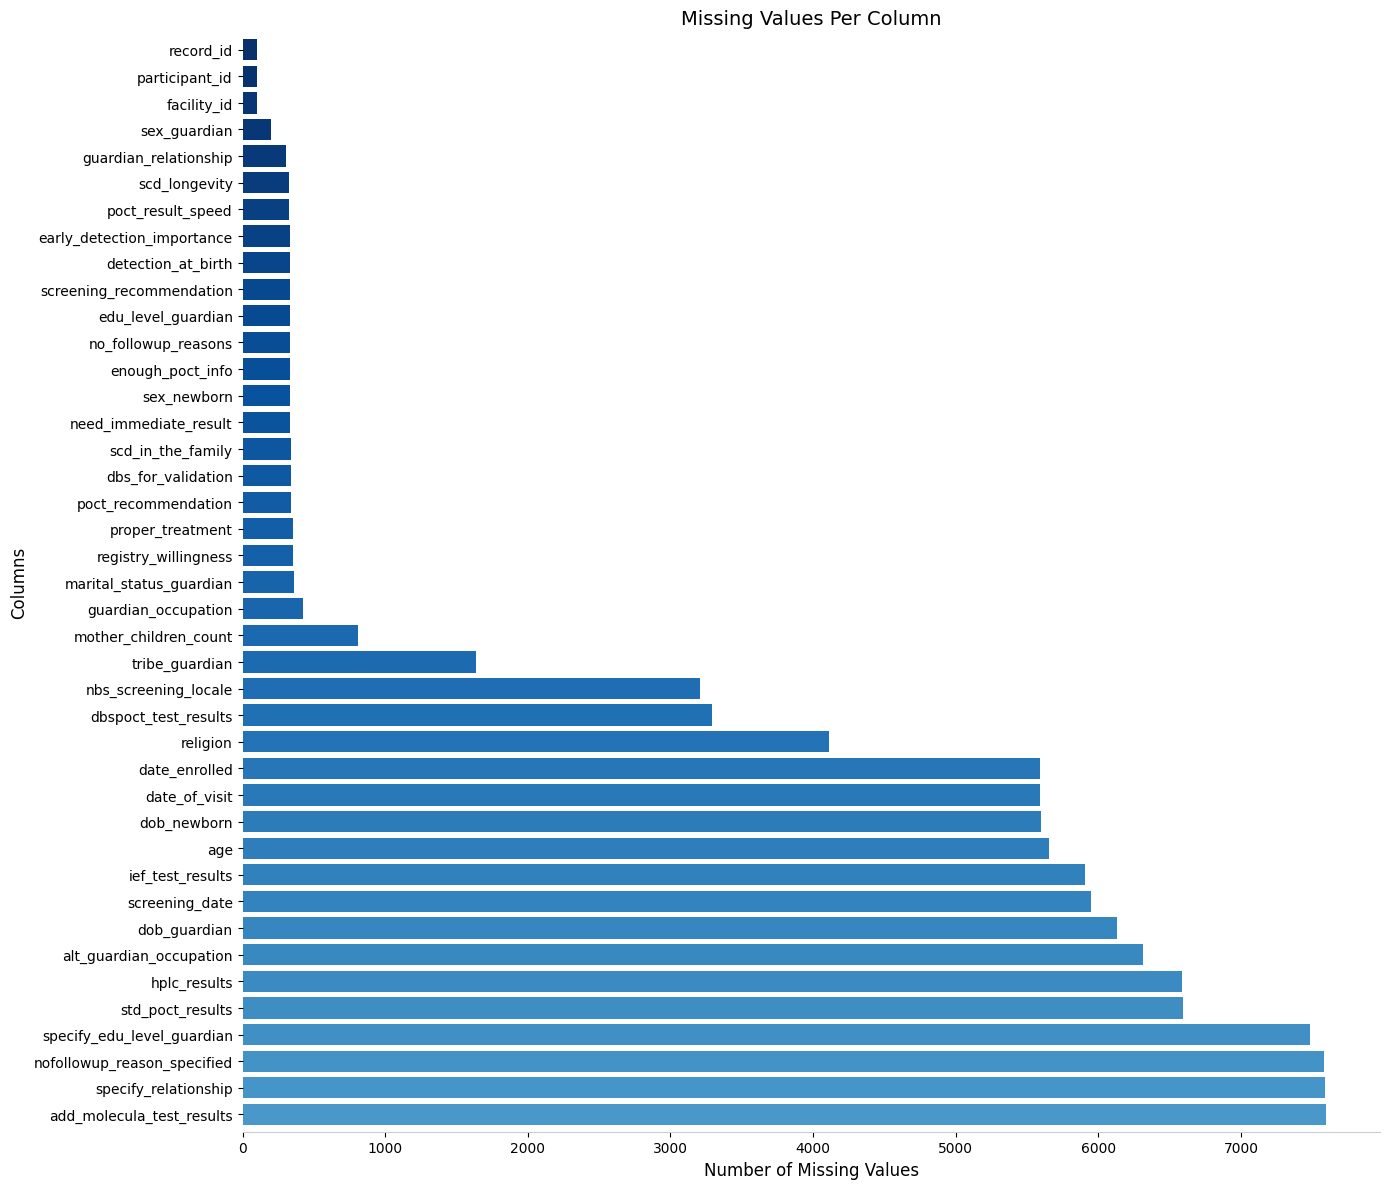

In [473]:
missing_summary = df_all_quant.isnull().sum()

missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

colors = plt.cm.Blues(np.linspace(0.6, 1, len(missing_summary)))

plt.figure(figsize=(14, 12)) 

missing_summary.plot(kind='barh', color=colors, width=0.8)  

plt.title('Missing Values Per Column', fontsize=14)
plt.xlabel('Number of Missing Values', fontsize=12)
plt.ylabel('Columns', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_color('#cccccc')  

plt.tight_layout()

plt.savefig("figures/eda/missing_values_plot.png", dpi=300, bbox_inches='tight')  # Save as PNG with high resolution

plt.show()

In [474]:
questionnaire_vars = [
    'dob_guardian','sex_guardian', 'age','guardian_relationship', 'detection_at_birth', 'scd_longevity', 
    'early_detection_importance','need_immediate_result', 'enough_poct_info', 'poct_result_speed',
    'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
    'proper_treatment', 'scd_in_the_family', 'registry_willingness',
    'no_followup_reasons', 'nofollowup_reason_specified', 'screening_date'
]

columns_to_keep = questionnaire_vars + ['country', 'facility_id','participant_id', 'record_id']

df_questionnaire = df_all_quant[columns_to_keep]

column_order = [
    'record_id', 'participant_id', 'facility_id','screening_date', 'dob_guardian', 'age','sex_guardian', 'guardian_relationship',
    'detection_at_birth', 'scd_longevity', 'early_detection_importance',
    'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
    'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
    'proper_treatment', 'scd_in_the_family', 'registry_willingness',
    'no_followup_reasons', 'nofollowup_reason_specified', 'country'
]

df_questionnaire = df_questionnaire[column_order]

print('Filtered DataFrame shape:', df_questionnaire.shape)

Filtered DataFrame shape: (7597, 23)


In [475]:
print('Filtered DataFrame shape:', df_questionnaire.shape)
df_questionnaire.head()

Filtered DataFrame shape: (7597, 23)


,record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,1,GH1,GH001,2024-02-20,1996-10-12,27,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,ghana
1,2,GH2,GH001,2024-02-20,NaT,<NA>,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,ghana
2,3,GH3,GH001,2024-02-20,1991-09-28,32,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,ghana
3,4,GH4,GH001,2024-02-20,NaT,26,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,ghana
4,5,GH5,GH001,2024-02-21,1993-01-01,31,Female,Mother,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,ghana


In [476]:
df_questionnaire.shape

(7597, 23)

In [477]:
df_questionnaire.columns

Index(['record_id', 'participant_id', 'facility_id', 'screening_date',
       'dob_guardian', 'age', 'sex_guardian', 'guardian_relationship',
       'detection_at_birth', 'scd_longevity', 'early_detection_importance',
       'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
       'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
       'proper_treatment', 'scd_in_the_family', 'registry_willingness',
       'no_followup_reasons', 'nofollowup_reason_specified', 'country'],
      dtype='object')

In [478]:
# Columns that are entirely missing
all_missing_cols = df_questionnaire.columns[df_questionnaire.isna().all()].tolist()
print(f"All-missing columns ({len(all_missing_cols)}):\n", all_missing_cols)

df_questionnaire_clean = df_questionnaire.drop(columns=all_missing_cols)

THRESH = 0.95
missing_frac = df_questionnaire.isna().mean().sort_values(ascending=False)
near_all_missing = missing_frac[missing_frac >= THRESH].index.tolist()
print(f"\nNear-all-missing (≥{int(THRESH*100)}% missing) ({len(near_all_missing)}):\n", near_all_missing)

missing_summary = pd.DataFrame({
    'n_missing': df_questionnaire.isna().sum(),
    'pct_missing': df_questionnaire.isna().mean()
}).sort_values('pct_missing', ascending=False)
print("\nMissingness summary (top 20):")
print(missing_summary.head(20))

All-missing columns (0):
 []

Near-all-missing (≥95% missing) (1):
 ['nofollowup_reason_specified']

Missingness summary (top 20):
                             n_missing  pct_missing
nofollowup_reason_specified       7580     0.997762
dob_guardian                      6127     0.806503
screening_date                    5950     0.783204
age                               5650     0.743715
registry_willingness               354     0.046597
proper_treatment                   351     0.046202
poct_recommendation                341     0.044886
dbs_for_validation                 338     0.044491
scd_in_the_family                  338     0.044491
need_immediate_result              336     0.044228
enough_poct_info                   334     0.043965
no_followup_reasons                334     0.043965
detection_at_birth                 332     0.043701
screening_recommendation           332     0.043701
early_detection_importance         330     0.043438
poct_result_speed                  32

In [479]:
df_questionnaire['country'] = (
    df_questionnaire['country']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'nigeria': 'Nigeria',
        'mali': 'Mali',
        'ghana': 'Ghana',
        'uganda': 'Uganda',
        'tanzania': 'Tanzania',
        'zim/zam': 'Zimbabwe/Zambia',
        'zimbabwe/zambia': 'Zimbabwe/Zambia'
    })
)

df_questionnaire['country'].value_counts(dropna=False)

country
Nigeria            2507
Zimbabwe/Zambia    1100
Mali               1011
Tanzania           1000
Ghana               999
Uganda              980
Name: count, dtype: int64

In [480]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,1,GH1,GH001,2024-02-20,1996-10-12,27,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,2,GH2,GH001,2024-02-20,NaT,<NA>,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,3,GH3,GH001,2024-02-20,1991-09-28,32,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,4,GH4,GH001,2024-02-20,NaT,26,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,5,GH5,GH001,2024-02-21,1993-01-01,31,Female,Mother,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


In [481]:
df_questionnaire['country'].value_counts(dropna=False)

country
Nigeria            2507
Zimbabwe/Zambia    1100
Mali               1011
Tanzania           1000
Ghana               999
Uganda              980
Name: count, dtype: int64

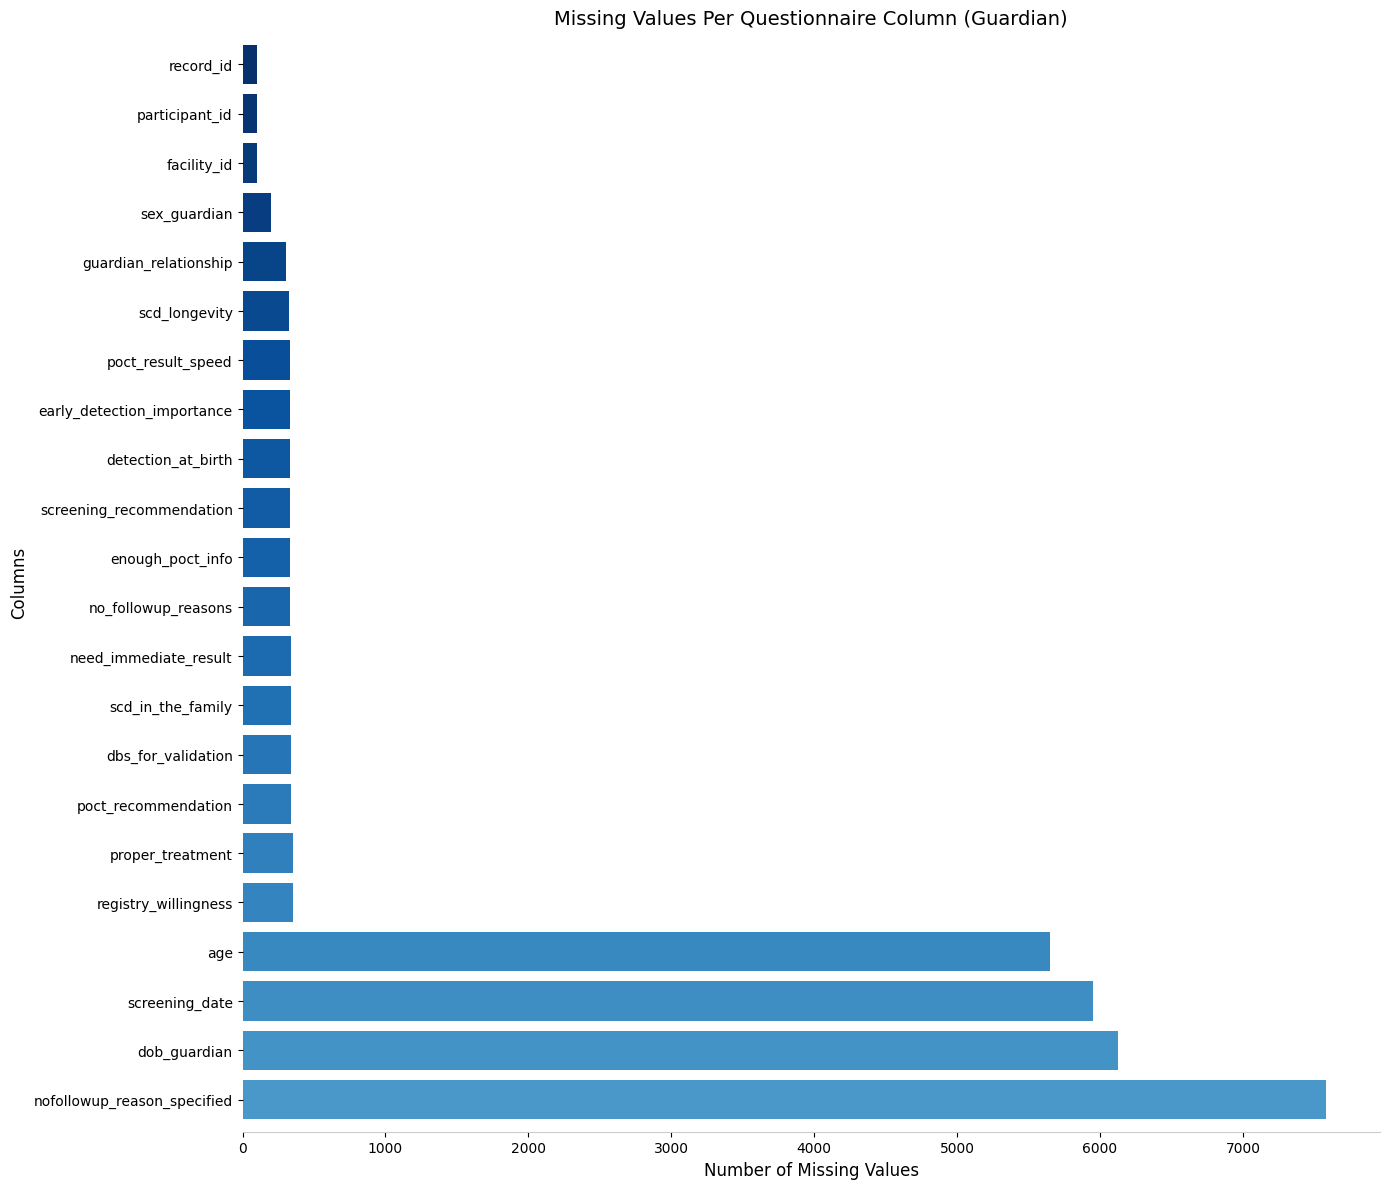

In [482]:
missing_summary = df_questionnaire.isnull().sum()

missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

colors = plt.cm.Blues(np.linspace(0.6, 1, len(missing_summary)))

plt.figure(figsize=(14, 12)) 

missing_summary.plot(kind='barh', color=colors, width=0.8) 

plt.title('Missing Values Per Questionnaire Column (Guardian)', fontsize=14)
plt.xlabel('Number of Missing Values', fontsize=12)
plt.ylabel('Columns', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_color('#cccccc')  

plt.tight_layout()

plt.savefig("figures/eda/missing_values_questionnaire.png", dpi=300, bbox_inches='tight')  

plt.show()

In [483]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,1,GH1,GH001,2024-02-20,1996-10-12,27,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,2,GH2,GH001,2024-02-20,NaT,<NA>,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,3,GH3,GH001,2024-02-20,1991-09-28,32,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,4,GH4,GH001,2024-02-20,NaT,26,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,5,GH5,GH001,2024-02-21,1993-01-01,31,Female,Mother,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


In [484]:
df_questionnaire.shape

(7597, 23)

In [485]:
df_questionnaire['country'].value_counts(dropna=False)

country
Nigeria            2507
Zimbabwe/Zambia    1100
Mali               1011
Tanzania           1000
Ghana               999
Uganda              980
Name: count, dtype: int64

In [486]:
country_remap = {
    'Zim_zam': 'Zimbabwe/Zambia'
}

actual_series = (
    df_questionnaire['country']
      .map(country_remap)
      .fillna(df_questionnaire['country'])
      .value_counts()
)

actual_df = actual_series.rename_axis('Country').reset_index(name='Actual')
actual_df

,Country,Actual
0,Nigeria,2507
1,Zimbabwe/Zambia,1100
2,Mali,1011
3,Tanzania,1000
4,Ghana,999
5,Uganda,980


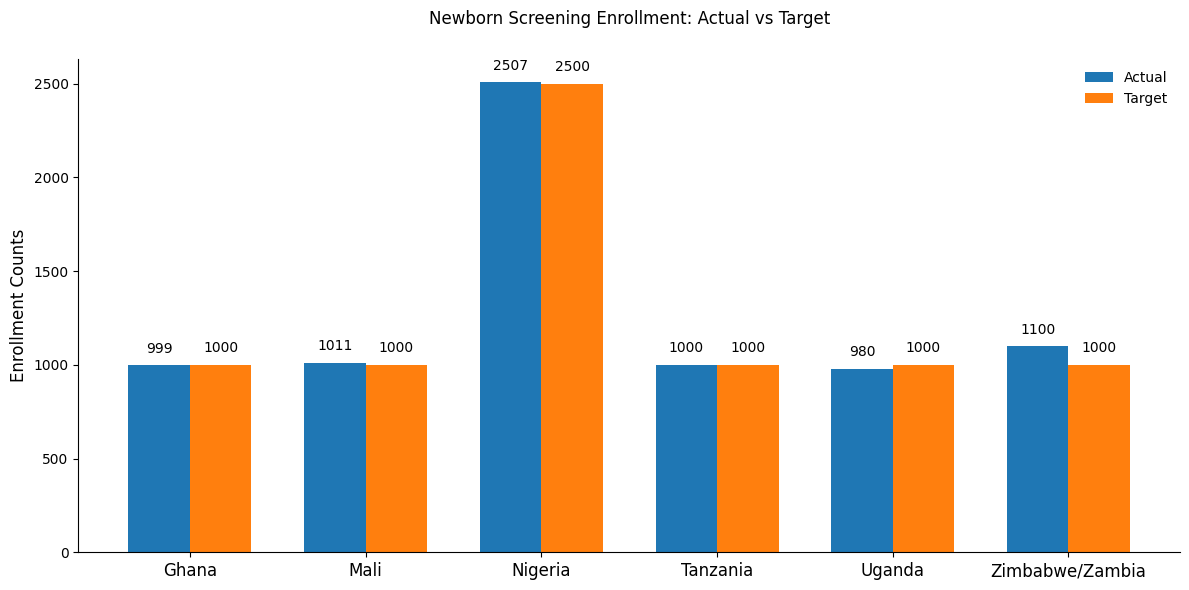

In [487]:
country_remap = {
    'Zim_zam': 'Zimbabwe/Zambia'
}

actual_series = (
    df_questionnaire['country']
      .map(country_remap)
      .fillna(df_questionnaire['country'])
      .value_counts()
)

actual_df = actual_series.rename_axis('Country').reset_index(name='Actual')

target_data = {
    "Ghana": 1000,
    "Mali": 1000,
    "Nigeria": 2500,        
    "Tanzania": 1000,
    "Uganda": 1000,
    "Zimbabwe/Zambia": 1000
}

order = ["Ghana", "Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]

df = pd.DataFrame({"Country": order})
df = df.merge(actual_df, on="Country", how="left")
df["Actual"] = df["Actual"].fillna(0).astype(int)
df["Target"] = df["Country"].map(target_data)

x = np.arange(len(df["Country"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, df["Actual"], width, label="Actual")
bars2 = ax.bar(x + width/2, df["Target"], width, label="Target")

for rect, cnt in zip(bars1, df["Actual"]):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + max(df["Target"])*0.02,
            f"{cnt}", ha="center", va="bottom", fontsize=10)

for rect, cnt in zip(bars2, df["Target"]):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + max(df["Target"])*0.02,
            f"{cnt}", ha="center", va="bottom", fontsize=10)

ax.grid(visible=False, which='both', axis='both')
ax.xaxis.grid(False)
ax.yaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Enrollment Counts", fontsize=12)
ax.set_title("Newborn Screening Enrollment: Actual vs Target", pad=25)
ax.title.set_y(1.02)  
ax.set_xticks(x)
ax.set_xticklabels(df["Country"], fontsize=12)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/eda/enrollment_actual_vs_target_clean.png", dpi=600, bbox_inches="tight")
plt.show()

In [488]:
df_questionnaire.head()

,record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,1,GH1,GH001,2024-02-20,1996-10-12,27,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,2,GH2,GH001,2024-02-20,NaT,<NA>,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,3,GH3,GH001,2024-02-20,1991-09-28,32,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,4,GH4,GH001,2024-02-20,NaT,26,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,5,GH5,GH001,2024-02-21,1993-01-01,31,Female,Mother,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


In [489]:
df_questionnaire['country'].value_counts(dropna=False)

country
Nigeria            2507
Zimbabwe/Zambia    1100
Mali               1011
Tanzania           1000
Ghana               999
Uganda              980
Name: count, dtype: int64

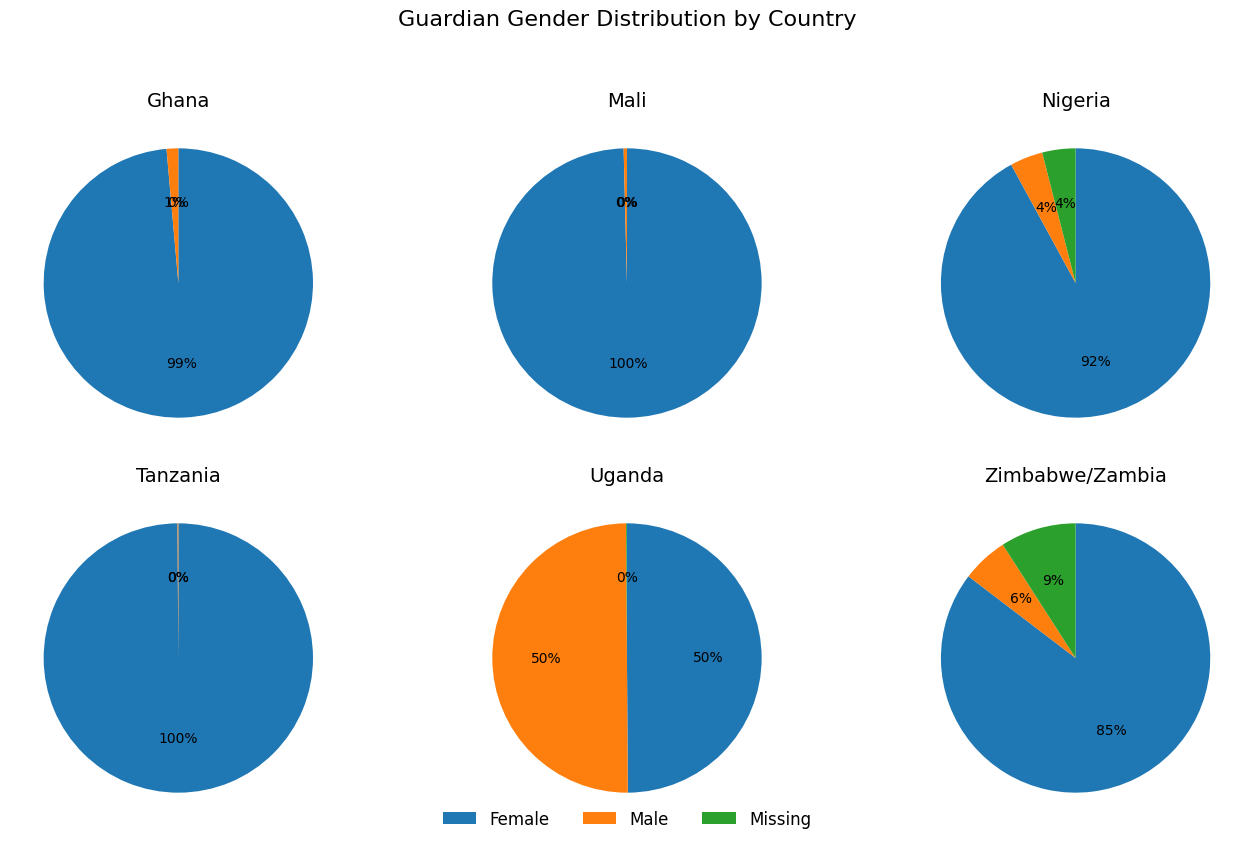

In [490]:
country_remap = {'Zim_zam': 'Zimbabwe/Zambia'}
dfp = df_questionnaire.copy()
dfp['Country'] = dfp['country'].map(country_remap).fillna(dfp['country'])

def _norm_sex(x):
    if pd.isna(x):
        return np.nan
    # numeric codes 0/1 -> Male/Female
    sx = str(x).strip()
    if sx in ('0', '1'):
        return 'Male' if sx == '0' else 'Female'

    s = sx.lower()
    if s in ('m', 'male'):   return 'Male'
    if s in ('f', 'female'): return 'Female'
    return np.nan

dfp['sex_norm'] = dfp['sex_guardian'].apply(_norm_sex).astype('object')
dfp['sex_norm'] = dfp['sex_norm'].fillna('Missing')

counts = (
    dfp.groupby(['Country', 'sex_norm'])
       .size()
       .unstack(fill_value=0)
)

for col in ['Female', 'Male', 'Missing']:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[['Female', 'Male', 'Missing']]

order = ["Ghana", "Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]
counts = counts.reindex(order, fill_value=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

labels = ["Female", "Male", "Missing"]
wedges_for_legend = None

for i, country in enumerate(order):
    ax = axes[i]
    vals = counts.loc[country, labels].values
    total = vals.sum()

    if total == 0:
        ax.axis('off')
        ax.set_title(country, fontsize=14)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
        continue

    wedges, texts, autotexts = ax.pie(
        vals, autopct="%1.0f%%", startangle=90, counterclock=False
    )
    ax.set_title(country, fontsize=14)

    if wedges_for_legend is None:
        wedges_for_legend = wedges 

if wedges_for_legend is not None:
    fig.legend(wedges_for_legend, labels, loc="lower center", ncol=3, frameon=False, fontsize=12)

plt.suptitle("Guardian Gender Distribution by Country", fontsize=16, y=1.04)
plt.tight_layout()
plt.savefig("figures/eda/guardian_sex_pies_combined_biglegend.png", dpi=300, bbox_inches="tight")
plt.show()

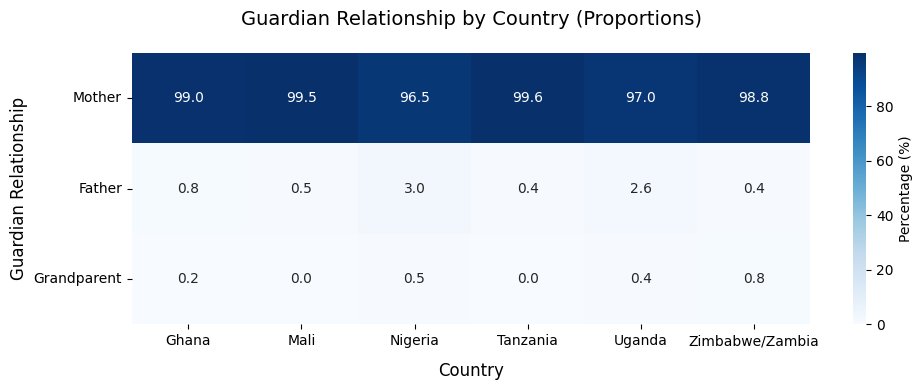

In [491]:
country_remap = {'Zim_zam': 'Zimbabwe/Zambia'}

REL_KEEP = ['Mother', 'Father', 'Grandparent']

COUNTRY_ORDER = ["Ghana", "Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]

dfp = df_questionnaire.copy()
dfp['Country'] = dfp['country'].map(country_remap).fillna(dfp['country'])

mask = dfp['guardian_relationship'].isin(REL_KEEP)
counts = (
    dfp.loc[mask]
       .groupby(['Country', 'guardian_relationship'])
       .size()
       .unstack(fill_value=0)
)

for col in REL_KEEP:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[REL_KEEP]

counts = counts.reindex(COUNTRY_ORDER, fill_value=0)

row_totals = counts.sum(axis=1)
df_perc = (counts.div(row_totals.replace(0, np.nan), axis=0) * 100).fillna(0.0)

df_perc_T = df_perc.T

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_perc_T, annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={'label': 'Percentage (%)'}
)

ax.set_title("Guardian Relationship by Country (Proportions)", fontsize=14, pad=20)
ax.set_ylabel("Guardian Relationship", fontsize=12)
ax.set_xlabel("Country", fontsize=12, labelpad=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("figures/eda/guardian_relationship_heatmap_horizontal_labels.png", dpi=300, bbox_inches="tight")
plt.show()

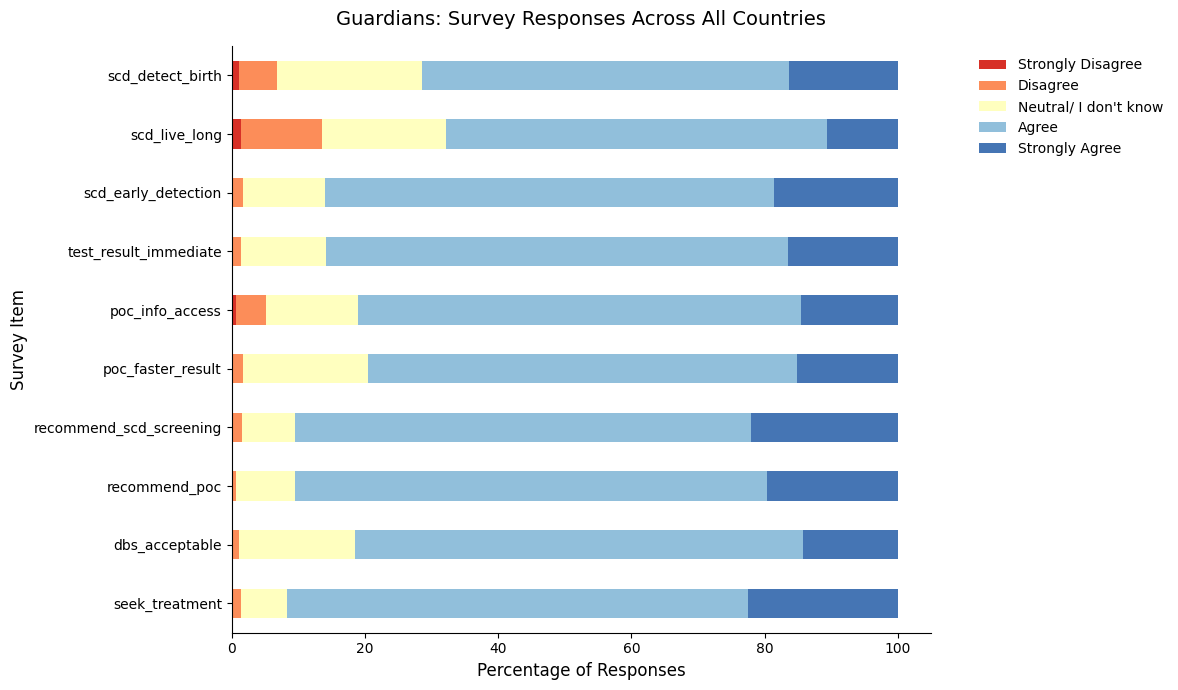

In [492]:
code_to_col = {
    "scd_detect_birth":        "detection_at_birth",
    "scd_live_long":           "scd_longevity",
    "scd_early_detection":     "early_detection_importance",
    "test_result_immediate":   "need_immediate_result",
    "poc_info_access":         "enough_poct_info",
    "poc_faster_result":       "poct_result_speed",
    "recommend_scd_screening": "screening_recommendation",
    "recommend_poc":           "poct_recommendation",
    "dbs_acceptable":          "dbs_for_validation",
    "seek_treatment":          "proper_treatment",
}

code_to_col = {k: v for k, v in code_to_col.items() if v in df_questionnaire.columns}

likert_levels = ["Strongly Disagree", "Disagree", "Neutral/ I don't know", "Agree", "Strongly Agree"]

rows = []
for code, col in code_to_col.items():
    s = df_questionnaire[col]
    row = {"Item": code}
    total_non_missing = s.notna().sum()
    for lvl in likert_levels:
        row[lvl] = (s == lvl).sum()
    row["Missing"] = s.isna().sum()
    row["_total_non_missing"] = total_non_missing
    rows.append(row)

df_counts = pd.DataFrame(rows)

df_percent = df_counts.copy()
for lvl in likert_levels:
    df_percent[lvl] = np.where(
        df_counts["_total_non_missing"] > 0,
        df_counts[lvl] / df_counts["_total_non_missing"] * 100.0,
        0.0
    )

order = [
    "scd_detect_birth", "scd_live_long", "scd_early_detection",
    "test_result_immediate", "poc_info_access", "poc_faster_result",
    "recommend_scd_screening", "recommend_poc",
    "dbs_acceptable", "seek_treatment"
]
order = [c for c in order if c in df_percent["Item"].values]  
df_percent = df_percent.set_index("Item").loc[order]
df_percent = df_percent.iloc[::-1]  

fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#d73027", "#fc8d59", "#ffffbf", "#91bfdb", "#4575b4"]  # same palette
df_percent[likert_levels].plot(kind="barh", stacked=True, ax=ax, color=colors)

ax.set_xlabel("Percentage of Responses", fontsize=12)
ax.set_ylabel("Survey Item", fontsize=12)
ax.set_title("Guardians: Survey Responses Across All Countries", fontsize=14, pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)  

ax.legend(title=None, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("figures/eda/likert_combined_all_countries_top_scd_detect_birth.png", dpi=300, bbox_inches="tight")
plt.show()

In [493]:
df_questionnaire.head(1)

,record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,1,GH1,GH001,2024-02-20,1996-10-12,27,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana


In [494]:
df_questionnaire['detection_at_birth'].value_counts(dropna=False)

detection_at_birth
Agree                    4004
Neutral/ I don't know    1588
Strongly Agree           1183
Disagree                  412
NaN                       332
Strongly Disagree          78
Name: count, dtype: int64

In [495]:
df_questionnaire.columns

Index(['record_id', 'participant_id', 'facility_id', 'screening_date',
       'dob_guardian', 'age', 'sex_guardian', 'guardian_relationship',
       'detection_at_birth', 'scd_longevity', 'early_detection_importance',
       'need_immediate_result', 'enough_poct_info', 'poct_result_speed',
       'screening_recommendation', 'poct_recommendation', 'dbs_for_validation',
       'proper_treatment', 'scd_in_the_family', 'registry_willingness',
       'no_followup_reasons', 'nofollowup_reason_specified', 'country'],
      dtype='object')

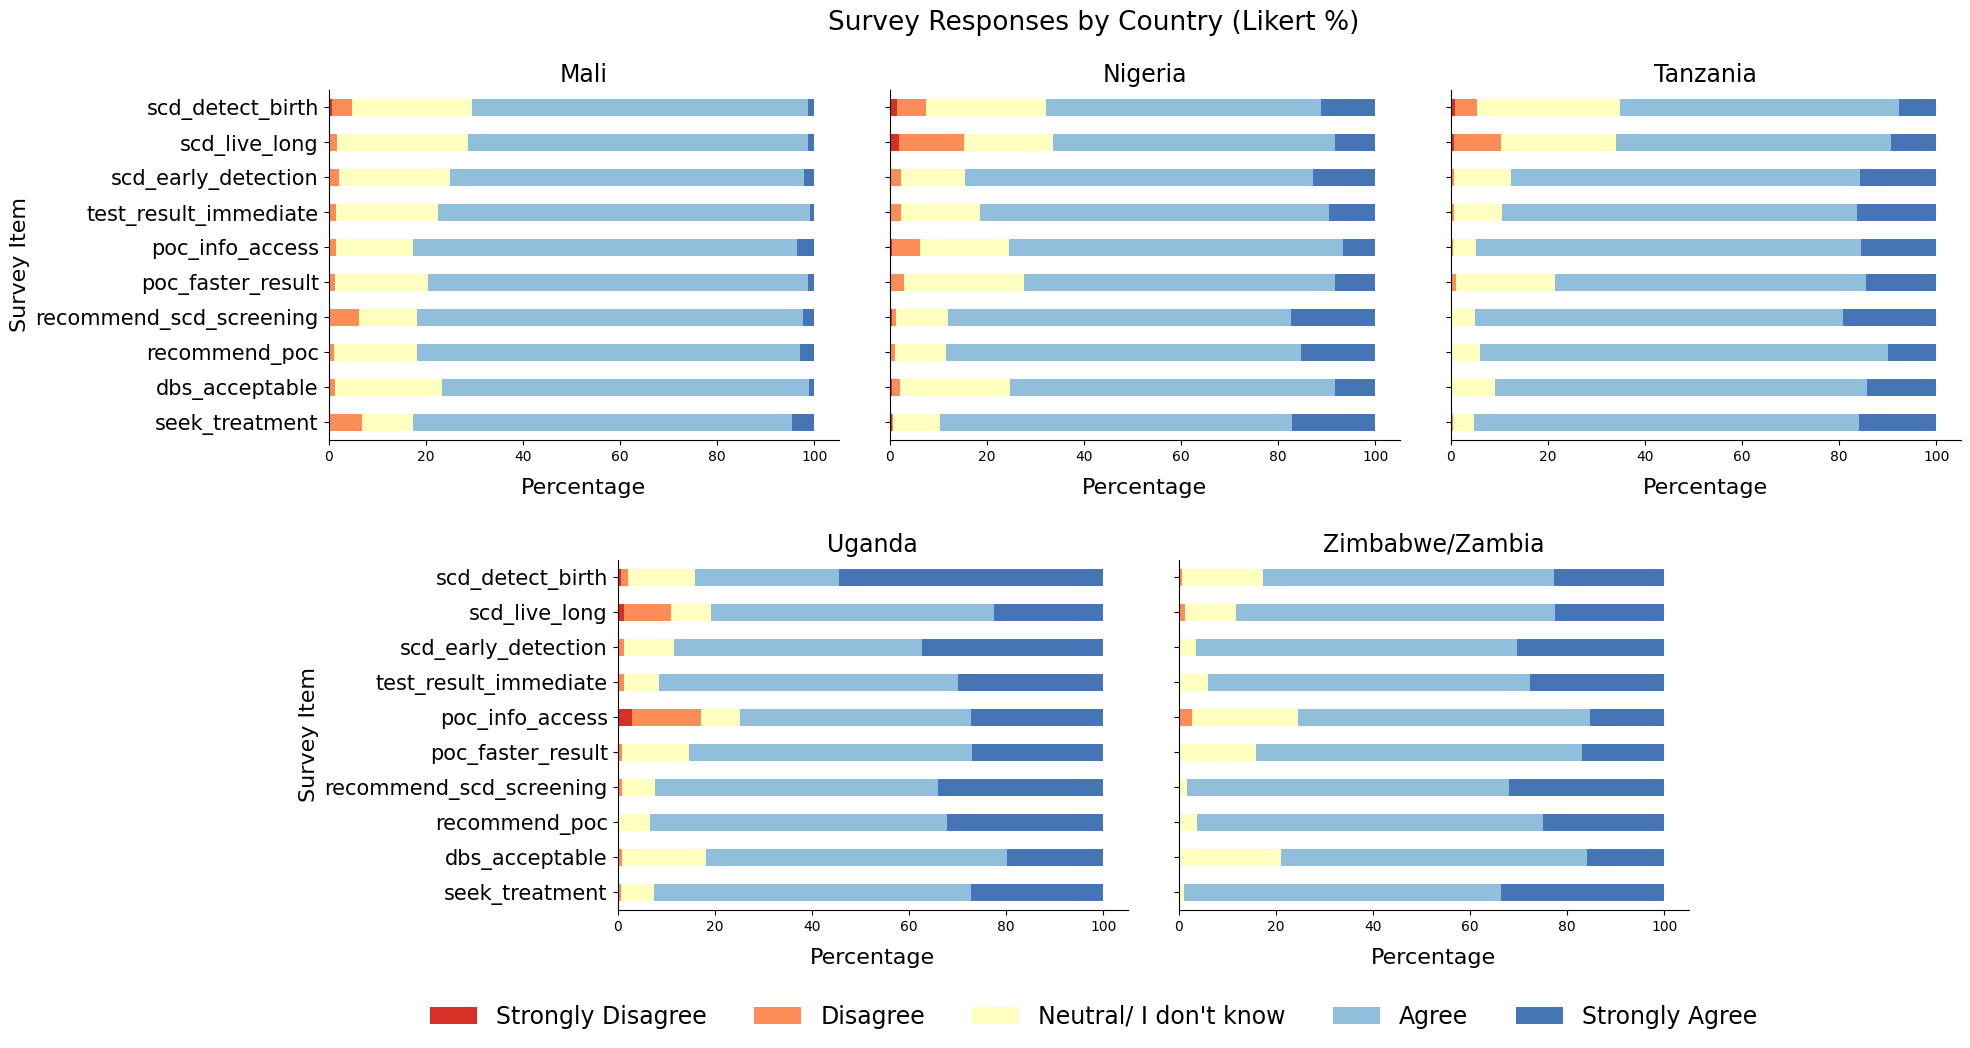

In [496]:
CODE_TO_COL = {
    "scd_detect_birth":        "detection_at_birth",
    "scd_live_long":           "scd_longevity",
    "scd_early_detection":     "early_detection_importance",
    "test_result_immediate":   "need_immediate_result",
    "poc_info_access":         "enough_poct_info",
    "poc_faster_result":       "poct_result_speed",
    "recommend_scd_screening": "screening_recommendation",
    "recommend_poc":           "poct_recommendation",
    "dbs_acceptable":          "dbs_for_validation",
    "seek_treatment":          "proper_treatment",
}

ORDER = [
    "scd_detect_birth", "scd_live_long", "scd_early_detection",
    "test_result_immediate", "poc_info_access", "poc_faster_result",
    "recommend_scd_screening", "recommend_poc", "dbs_acceptable", "seek_treatment"
]

# LIKERT_COLS = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]

LIKERT_COLS = ["Strongly Disagree", "Disagree", "Neutral/ I don't know", "Agree", "Strongly Agree"]

COLORS = ["#d73027", "#fc8d59", "#ffffbf", "#91bfdb", "#4575b4"]

COUNTRIES = ["Mali", "Nigeria", "Tanzania", "Uganda", "Zimbabwe/Zambia"]

COUNTRY_REMAP = {"Zim_zam": "Zimbabwe/Zambia"}

def likert_percent_for_country(dfq: pd.DataFrame, country_label: str) -> pd.DataFrame:
    """
    Compute a Likert % table (rows=items, cols=LIKERT_COLS) for a single country.
    Percentages exclude missing (NaN). Returns rows in ORDER (reversed for barh).
    """
    dfp = dfq.copy()
    dfp["Country"] = dfp["country"].map(COUNTRY_REMAP).fillna(dfp["country"])
    sub = dfp[dfp["Country"] == country_label]
    if sub.empty:
        return pd.DataFrame(columns=LIKERT_COLS, index=list(reversed(ORDER)))
    rows = []
    for code, col in CODE_TO_COL.items():
        if col not in sub.columns:
            rows.append({"Item": code, **{k: 0.0 for k in LIKERT_COLS}, "_n": 0})
            continue
        s = sub[col]
        n_nonmiss = s.notna().sum()
        counts = {lvl: int((s == lvl).sum()) for lvl in LIKERT_COLS}
        if n_nonmiss > 0:
            pct = {lvl: counts[lvl] / n_nonmiss * 100.0 for lvl in LIKERT_COLS}
        else:
            pct = {lvl: 0.0 for lvl in LIKERT_COLS}
        row = {"Item": code, **pct, "_n": n_nonmiss}
        rows.append(row)

    dfpct = pd.DataFrame(rows).set_index("Item").loc[ORDER, LIKERT_COLS]
    return dfpct.iloc[::-1]

dfs = {cty: likert_percent_for_country(df_questionnaire, cty) for cty in COUNTRIES}
fig = plt.figure(figsize=(17, 10))

ax1 = fig.add_axes([0.05, 0.55, 0.3, 0.35])  
ax2 = fig.add_axes([0.38, 0.55, 0.3, 0.35])  
ax3 = fig.add_axes([0.71, 0.55, 0.3, 0.35])  

ax4 = fig.add_axes([0.22, 0.08, 0.3, 0.35])  
ax5 = fig.add_axes([0.55, 0.08, 0.3, 0.35])  

axes = [ax1, ax2, ax3, ax4, ax5]

for ax, country in zip(axes, COUNTRIES):
    dff = dfs[country]
    if dff.empty or dff.to_numpy().sum() == 0:
        ax.axis("off")
        ax.set_title(country, fontsize=17)
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
        continue

    dff[LIKERT_COLS].plot(kind="barh", stacked=True, ax=ax, color=COLORS, legend=False)

    ax.set_title(country, fontsize=17)
    ax.set_xlabel("Percentage", fontsize=16, labelpad=10)
    ax.tick_params(axis="y", labelsize=15)

    if country not in ["Mali", "Uganda"]:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Survey Item", fontsize=16)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

fig.legend(LIKERT_COLS, loc="lower center", ncol=5, frameon=False, fontsize=17,
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle("Survey Responses by Country (Likert %)", y=0.98, fontsize=19)
plt.savefig("figures/eda/likert_subplots_centered_manual_from_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

In [497]:
print(df_questionnaire.shape)
df_questionnaire.head()

(7597, 23)


,record_id,participant_id,facility_id,screening_date,dob_guardian,age,sex_guardian,guardian_relationship,detection_at_birth,scd_longevity,early_detection_importance,need_immediate_result,enough_poct_info,poct_result_speed,screening_recommendation,poct_recommendation,dbs_for_validation,proper_treatment,scd_in_the_family,registry_willingness,no_followup_reasons,nofollowup_reason_specified,country
0,1,GH1,GH001,2024-02-20,1996-10-12,27,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
1,2,GH2,GH001,2024-02-20,NaT,<NA>,Female,Mother,Strongly Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Neutral/ I don't know,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,I don't know,Yes,Yes,NaN,Ghana
2,3,GH3,GH001,2024-02-20,1991-09-28,32,Female,Mother,Neutral/ I don't know,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
3,4,GH4,GH001,2024-02-20,NaT,26,Female,Mother,Strongly Agree,Agree,Strongly Agree,Disagree,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,No,Yes,Yes,NaN,Ghana
4,5,GH5,GH001,2024-02-21,1993-01-01,31,Female,Mother,Agree,Neutral/ I don't know,Neutral/ I don't know,Neutral/ I don't know,Agree,Agree,Agree,Agree,Agree,Agree,No,Yes,Yes,NaN,Ghana


In [498]:
df_questionnaire['country'].value_counts(dropna=False)

country
Nigeria            2507
Zimbabwe/Zambia    1100
Mali               1011
Tanzania           1000
Ghana               999
Uganda              980
Name: count, dtype: int64

In [499]:
df_questionnaire.to_excel('../data/clean/clean.xlsx', index=False)

In [500]:
df_questionnaire.to_excel('../data/clean/quantitative.xlsx', index=False)

In [501]:
df_questionnaire[df_questionnaire['country'] == 'Nigeria']['age'].value_counts(dropna=False)

age
<NA>    2507
Name: count, dtype: Int64